# Task
Perform an analysis to determine if positive audience reactions improve content popularity, using the "raw.csv" dataset.

## Load Dataset

### Subtask:
Load the 'raw.csv' dataset into a pandas DataFrame to begin the analysis.


**Reasoning**:
Load the 'raw.csv' dataset into a pandas DataFrame and display the first few rows to verify successful loading.



In [ ]:
import pandas as pd
df = pd.read_csv('raw.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
0,SM_100000,Instagram,text,Sports,ur,UK,2024-12-10 00:00:00,#tech #funny #music,2319102,122058,15800,861,0.0598,0.464,1
1,SM_100001,Instagram,carousel,Sports,ur,Brazil,2024-10-13 00:00:00,#news #fyp #funny #ai #trending,2538464,110368,11289,54887,0.0695,-0.800,1
2,SM_100002,YouTube Shorts,video,Technology,ur,UK,2024-05-03 00:00:00,#ai #news,1051176,87598,47196,44132,0.1702,0.416,0
3,SM_100003,X,text,Politics,ur,US,2024-08-04 00:00:00,#ai #funny,5271440,329465,774,59736,0.0740,0.877,1
4,SM_100004,YouTube Shorts,text,Education,es,US,2024-03-28 00:00:00,#news #ai #viral #funny #fyp,3186256,199141,5316,83105,0.0903,0.223,1


## Initial Data Inspection

### Subtask:
Perform an initial inspection of the dataset. This includes displaying the first few rows, checking data types with `.info()`, and reviewing basic descriptive statistics with `.describe()` to understand the data's structure and content.


**Reasoning**:
To understand the data types, non-null counts, and memory usage of the DataFrame, I will print a concise summary using the `.info()` method as instructed.



In [ ]:
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          2000 non-null   object 
 1   platform         2000 non-null   object 
 2   content_type     2000 non-null   object 
 3   topic            2000 non-null   object 
 4   language         2000 non-null   object 
 5   region           2000 non-null   object 
 6   post_datetime    2000 non-null   object 
 7   hashtags         2000 non-null   object 
 8   views            2000 non-null   int64  
 9   likes            2000 non-null   int64  
 10  comments         2000 non-null   int64  
 11  shares           2000 non-null   int64  
 12  engagement_rate  2000 non-null   float64
 13  sentiment_score  2000 non-null   float64
 14  is_viral         2000 non-null   int64  
dtypes: float64(2), int64(5), object(8)
memory usage: 234.5+ KB


**Reasoning**:
To get a quick overview of the central tendency, dispersion, and shape of the dataset's distribution for numerical columns, I will use the `.describe()` method as instructed.



In [ ]:
print("\nDescriptive Statistics:")
df.describe()


Descriptive Statistics:


,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.284860e+06,245329.244000,24786.929000,49936.981500,0.157852,-0.000566,0.699000
std,3.246193e+06,145032.423582,14433.288364,29012.818697,0.535457,0.574911,0.458807
min,4.380000e+03,292.000000,14.000000,127.000000,0.035700,-1.000000,0.000000
25%,1.652742e+06,118903.750000,12337.750000,25698.750000,0.057975,-0.507000,0.000000
50%,3.469408e+06,239831.000000,24519.500000,50212.000000,0.084500,0.001000,1.000000
75%,6.348078e+06,372323.500000,37116.250000,75433.000000,0.142525,0.495250,1.000000
max,1.437179e+07,499983.000000,49989.000000,99977.000000,12.573200,0.999000,1.000000


## Handle Missing Values

### Subtask:
Identify and address any missing values in the dataset. This step will involve checking the count of nulls per column and deciding on an appropriate strategy (e.g., imputation, removal) based on the column's nature and the extent of missingness.


In [ ]:
df.isnull().sum()

,0
platform,0
content_type,0
topic,0
language,0
region,0
post_datetime,0
hashtags,0
views,0
likes,0
comments,0


## Handle Duplicate Rows

### Subtask:
Check for and remove any duplicate rows from the dataset to ensure data uniqueness and prevent bias in the analysis.


**Reasoning**:
To ensure data uniqueness and prevent bias in the analysis, I will first check for duplicate rows in the DataFrame and then remove them if any exist. I will also print the shape of the DataFrame before and after the operation to confirm the changes.



In [ ]:
print("Original DataFrame shape:", df.shape)
duplicate_rows_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows_count}")

if duplicate_rows_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed. New DataFrame shape:", df.shape)
else:
    print("No duplicate rows found.")

Original DataFrame shape: (2000, 15)
Number of duplicate rows found: 0
No duplicate rows found.


## Feature Engineering and Selection

### Subtask:
Based on the initial inspection and the hypothesis ('positive audience reactions improve content popularity'), identify and select suitable columns related to 'positive audience reactions' and 'views'. This might involve creating new features or dropping irrelevant columns.


**Reasoning**:
To streamline the dataset for analysis, I will drop the 'post_id' column as instructed, as it is not relevant to the analysis of content popularity based on audience reactions.



In [ ]:
df_cleaned = df.drop(columns=['post_id'])
print("Dropped 'post_id' column. Displaying the first 5 rows of the modified DataFrame:")
df_cleaned.head()

Dropped 'post_id' column. Displaying the first 5 rows of the modified DataFrame:


,platform,content_type,topic,language,region,post_datetime,hashtags,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
0,Instagram,text,Sports,ur,UK,2024-12-10 00:00:00,#tech #funny #music,2319102,122058,15800,861,0.0598,0.464,1
1,Instagram,carousel,Sports,ur,Brazil,2024-10-13 00:00:00,#news #fyp #funny #ai #trending,2538464,110368,11289,54887,0.0695,-0.800,1
2,YouTube Shorts,video,Technology,ur,UK,2024-05-03 00:00:00,#ai #news,1051176,87598,47196,44132,0.1702,0.416,0
3,X,text,Politics,ur,US,2024-08-04 00:00:00,#ai #funny,5271440,329465,774,59736,0.0740,0.877,1
4,YouTube Shorts,text,Education,es,US,2024-03-28 00:00:00,#news #ai #viral #funny #fyp,3186256,199141,5316,83105,0.0903,0.223,1


**Reasoning**:
The previous step created `df_cleaned` by dropping the 'post_id' column. As per the instructions, the modified DataFrame should be assigned back to `df`. After this, I will review the remaining columns by displaying them, confirming the selection of columns relevant to 'positive audience reactions' and 'content popularity' for the analysis, thus fulfilling the subtask instructions.



In [ ]:
df = df_cleaned.copy()
print("DataFrame after dropping 'post_id' and assigning back to df. Current columns:")
print(df.columns.tolist())

print("\nIdentified columns for positive audience reactions: ['likes', 'comments', 'shares', 'engagement_rate', 'sentiment_score']")
print("Identified column for content popularity: ['views']")

DataFrame after dropping 'post_id' and assigning back to df. Current columns:
['platform', 'content_type', 'topic', 'language', 'region', 'post_datetime', 'hashtags', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'sentiment_score', 'is_viral']

Identified columns for positive audience reactions: ['likes', 'comments', 'shares', 'engagement_rate', 'sentiment_score']
Identified column for content popularity: ['views']


## Encode Categorical Features

### Subtask:
Identify categorical features and apply appropriate encoding techniques (e.g., One-Hot Encoding) to convert them into a numerical format suitable for correlation analysis and statistical modeling.


**Reasoning**:
First, I need to convert the 'post_datetime' column to a datetime object, as it is currently an 'object' type but represents temporal data, not a categorical feature suitable for one-hot encoding. This will ensure it's excluded when selecting categorical columns for encoding.



In [ ]:
df['post_datetime'] = pd.to_datetime(df['post_datetime'])
print("Converted 'post_datetime' to datetime objects. Info for this column:")
df['post_datetime'].info()

Converted 'post_datetime' to datetime objects. Info for this column:
<class 'pandas.core.series.Series'>
RangeIndex: 2000 entries, 0 to 1999
Series name: post_datetime
Non-Null Count  Dtype         
--------------  -----         
2000 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 15.8 KB


**Reasoning**:
Now that the 'post_datetime' column has been correctly converted to datetime objects, I will identify the remaining categorical columns (object type) and apply one-hot encoding using `pd.get_dummies()`. Finally, I will concatenate these new encoded features with the original DataFrame and display its head and info to verify the transformation.



In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

# Exclude 'hashtags' from one-hot encoding as it can generate too many columns and requires special handling.
# For this analysis, we will focus on other explicit categorical features.
categorical_cols = categorical_cols.drop('hashtags', errors='ignore')

print(f"Categorical columns to be one-hot encoded: {categorical_cols.tolist()}")

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nDataFrame after one-hot encoding. Displaying the first 5 rows:")
print(df_encoded.head())

print("\nDataFrame Info after one-hot encoding:")
df_encoded.info()

Categorical columns to be one-hot encoded: ['platform', 'content_type', 'topic', 'language', 'region']

DataFrame after one-hot encoding. Displaying the first 5 rows:
  post_datetime                         hashtags    views   likes  comments  \
0    2024-12-10              #tech #funny #music  2319102  122058     15800   
1    2024-10-13  #news #fyp #funny #ai #trending  2538464  110368     11289   
2    2024-05-03                        #ai #news  1051176   87598     47196   
3    2024-08-04                       #ai #funny  5271440  329465       774   
4    2024-03-28     #news #ai #viral #funny #fyp  3186256  199141      5316   

   shares  engagement_rate  sentiment_score  is_viral  platform_TikTok  ...  \
0     861           0.0598            0.464         1            False  ...   
1   54887           0.0695           -0.800         1            False  ...   
2   44132           0.1702            0.416         0            False  ...   
3   59736           0.0740            0.87

## Apply TF-IDF for Hashtags

### Subtask:
Apply TF-IDF (Term Frequency-Inverse Document Frequency) to the 'hashtags' column to extract numerical features representing the importance of each hashtag. This will enrich the dataset with features derived from textual content.


**Reasoning**:
To apply TF-IDF, I will first import the `TfidfVectorizer` and then preprocess the 'hashtags' column by ensuring all values are strings and properly formatted for tokenization. After that, I will instantiate `TfidfVectorizer`, fit and transform the preprocessed data, convert the result to a DataFrame, and finally concatenate it with the main DataFrame.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Preprocess the 'hashtags' column
# Ensure all values are strings and concatenate them with spaces
# Remove '#' and split into individual words/phrases then join with space
def preprocess_hashtags(hashtags_str):
    if isinstance(hashtags_str, str):
        # Remove '#' characters and split by space, then join back with a single space
        # This handles cases like '#tag1 #tag2' -> 'tag1 tag2'
        # And also 'tag1#tag2' -> 'tag1 tag2' if needed, though input suggests spaces already
        clean_tags = [tag.strip() for tag in hashtags_str.replace('#', ' ').split() if tag.strip()]
        return ' '.join(clean_tags)
    return '' # Return empty string for non-string types to avoid errors

df_encoded['processed_hashtags'] = df_encoded['hashtags'].apply(preprocess_hashtags)

print("Preprocessed 'hashtags' column. Displaying first 5 rows of 'processed_hashtags':")
print(df_encoded[['hashtags', 'processed_hashtags']].head())

# Instantiate TfidfVectorizer
# Using a reasonable max_features to limit the number of columns, e.g., 100
tfidf_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')

# Fit and transform the preprocessed 'hashtags' column
tfidf_matrix = tfidf_vectorizer.fit_transform(df_encoded['processed_hashtags'])

# Convert the TF-IDF sparse matrix into a pandas DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out(), index=df_encoded.index)

print(f"\nTF-IDF matrix converted to DataFrame with {tfidf_df.shape[1]} features. Displaying the first 5 rows:")
print(tfidf_df.head())

# Concatenate the new TF-IDF DataFrame with the df_encoded DataFrame
df_encoded = pd.concat([df_encoded, tfidf_df], axis=1)

# Drop the original 'hashtags' column and the 'processed_hashtags' column as they are no longer needed
df_encoded = df_encoded.drop(columns=['hashtags', 'processed_hashtags'])

print("\nDataFrame after TF-IDF and concatenation. Displaying the first 5 rows:")
print(df_encoded.head())

print("\nDataFrame Info after TF-IDF:")
df_encoded.info()

Preprocessed 'hashtags' column. Displaying first 5 rows of 'processed_hashtags':
                          hashtags          processed_hashtags
0              #tech #funny #music            tech funny music
1  #news #fyp #funny #ai #trending  news fyp funny ai trending
2                        #ai #news                     ai news
3                       #ai #funny                    ai funny
4     #news #ai #viral #funny #fyp     news ai viral funny fyp

TF-IDF matrix converted to DataFrame with 8 features. Displaying the first 5 rows:
         ai     funny       fyp     music      news      tech  trending  \
0  0.000000  0.574960  0.000000  0.570679  0.000000  0.586299  0.000000   
1  0.450354  0.444732  0.456692  0.000000  0.447246  0.000000  0.436804   
2  0.709551  0.000000  0.000000  0.000000  0.704654  0.000000  0.000000   
3  0.711534  0.702652  0.000000  0.000000  0.000000  0.000000  0.000000   
4  0.448789  0.443186  0.455104  0.000000  0.445691  0.000000  0.000000   

      

## Standardize Numerical Features

### Subtask:
Standardize all numerical features, including those derived from TF-IDF, using techniques like StandardScaler to ensure they are on a similar scale. This is important for many machine learning algorithms and can improve model performance and interpretability.


**Reasoning**:
To ensure all numerical features, including the newly added TF-IDF features, are on a similar scale for consistent model performance and interpretability, I will re-apply `StandardScaler` to all columns in `df_encoded` that have a numerical data type (`int64` or `float64`). This will standardize the new TF-IDF features and re-confirm the standardization of the previously scaled numerical features.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify all numerical columns (int64 and float64) in the updated df_encoded
# Exclude post_datetime as it's a datetime object
numerical_cols_all = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"All numerical columns to be standardized: {numerical_cols_all}")

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit and transform all identified numerical columns
df_encoded[numerical_cols_all] = scaler.fit_transform(df_encoded[numerical_cols_all])

print("\nDataFrame with all numerical features (including TF-IDF) standardized. Displaying the first 5 rows of scaled columns:")
print(df_encoded[numerical_cols_all].head())

print("\nDescriptive Statistics of all standardized numerical features:")
print(df_encoded[numerical_cols_all].describe())

All numerical columns to be standardized: ['views', 'likes', 'comments', 'shares', 'engagement_rate', 'sentiment_score', 'is_viral', 'ai', 'funny', 'fyp', 'music', 'news', 'tech', 'trending', 'viral']

DataFrame with all numerical features (including TF-IDF) standardized. Displaying the first 5 rows of scaled columns:
      views     likes  comments    shares  engagement_rate  sentiment_score  \
0 -0.605709 -0.850169 -0.622809 -1.691951        -0.183164         0.808268   
1 -0.538117 -0.930792 -0.935428  0.170658        -0.165044        -1.390881   
2 -0.996395 -1.087830  1.552985 -0.200133         0.023067         0.724756   
3  0.303995  0.580262 -1.664135  0.337832        -0.156638         1.526819   
4 -0.338513 -0.318548 -1.349367  1.143505        -0.126189         0.388968   

   is_viral        ai     funny       fyp     music      news      tech  \
0  0.656213 -0.845463  1.287239 -0.827471  1.264883 -0.854322  1.334306   
1  0.656213  0.826752  0.800347  0.860899 -0.872068  0.

## Correlation Matrix Analysis

### Subtask:
Compute and visualize the correlation matrix for all features, including the new hashtag TF-IDF features. Pay special attention to the correlation of all features with the target column 'views' and the relationship between 'positive audience reactions' related features and 'views' to understand their linear relationships.


**Reasoning**:
To analyze the correlations between all features, including the newly added TF-IDF features, and 'views', I will compute the correlation matrix for all numerical and boolean columns in `df_encoded` and visualize it using a heatmap. Then, I will print the correlations with the 'views' column, sorted in descending order.



Correlation matrix computed for all features including TF-IDF.


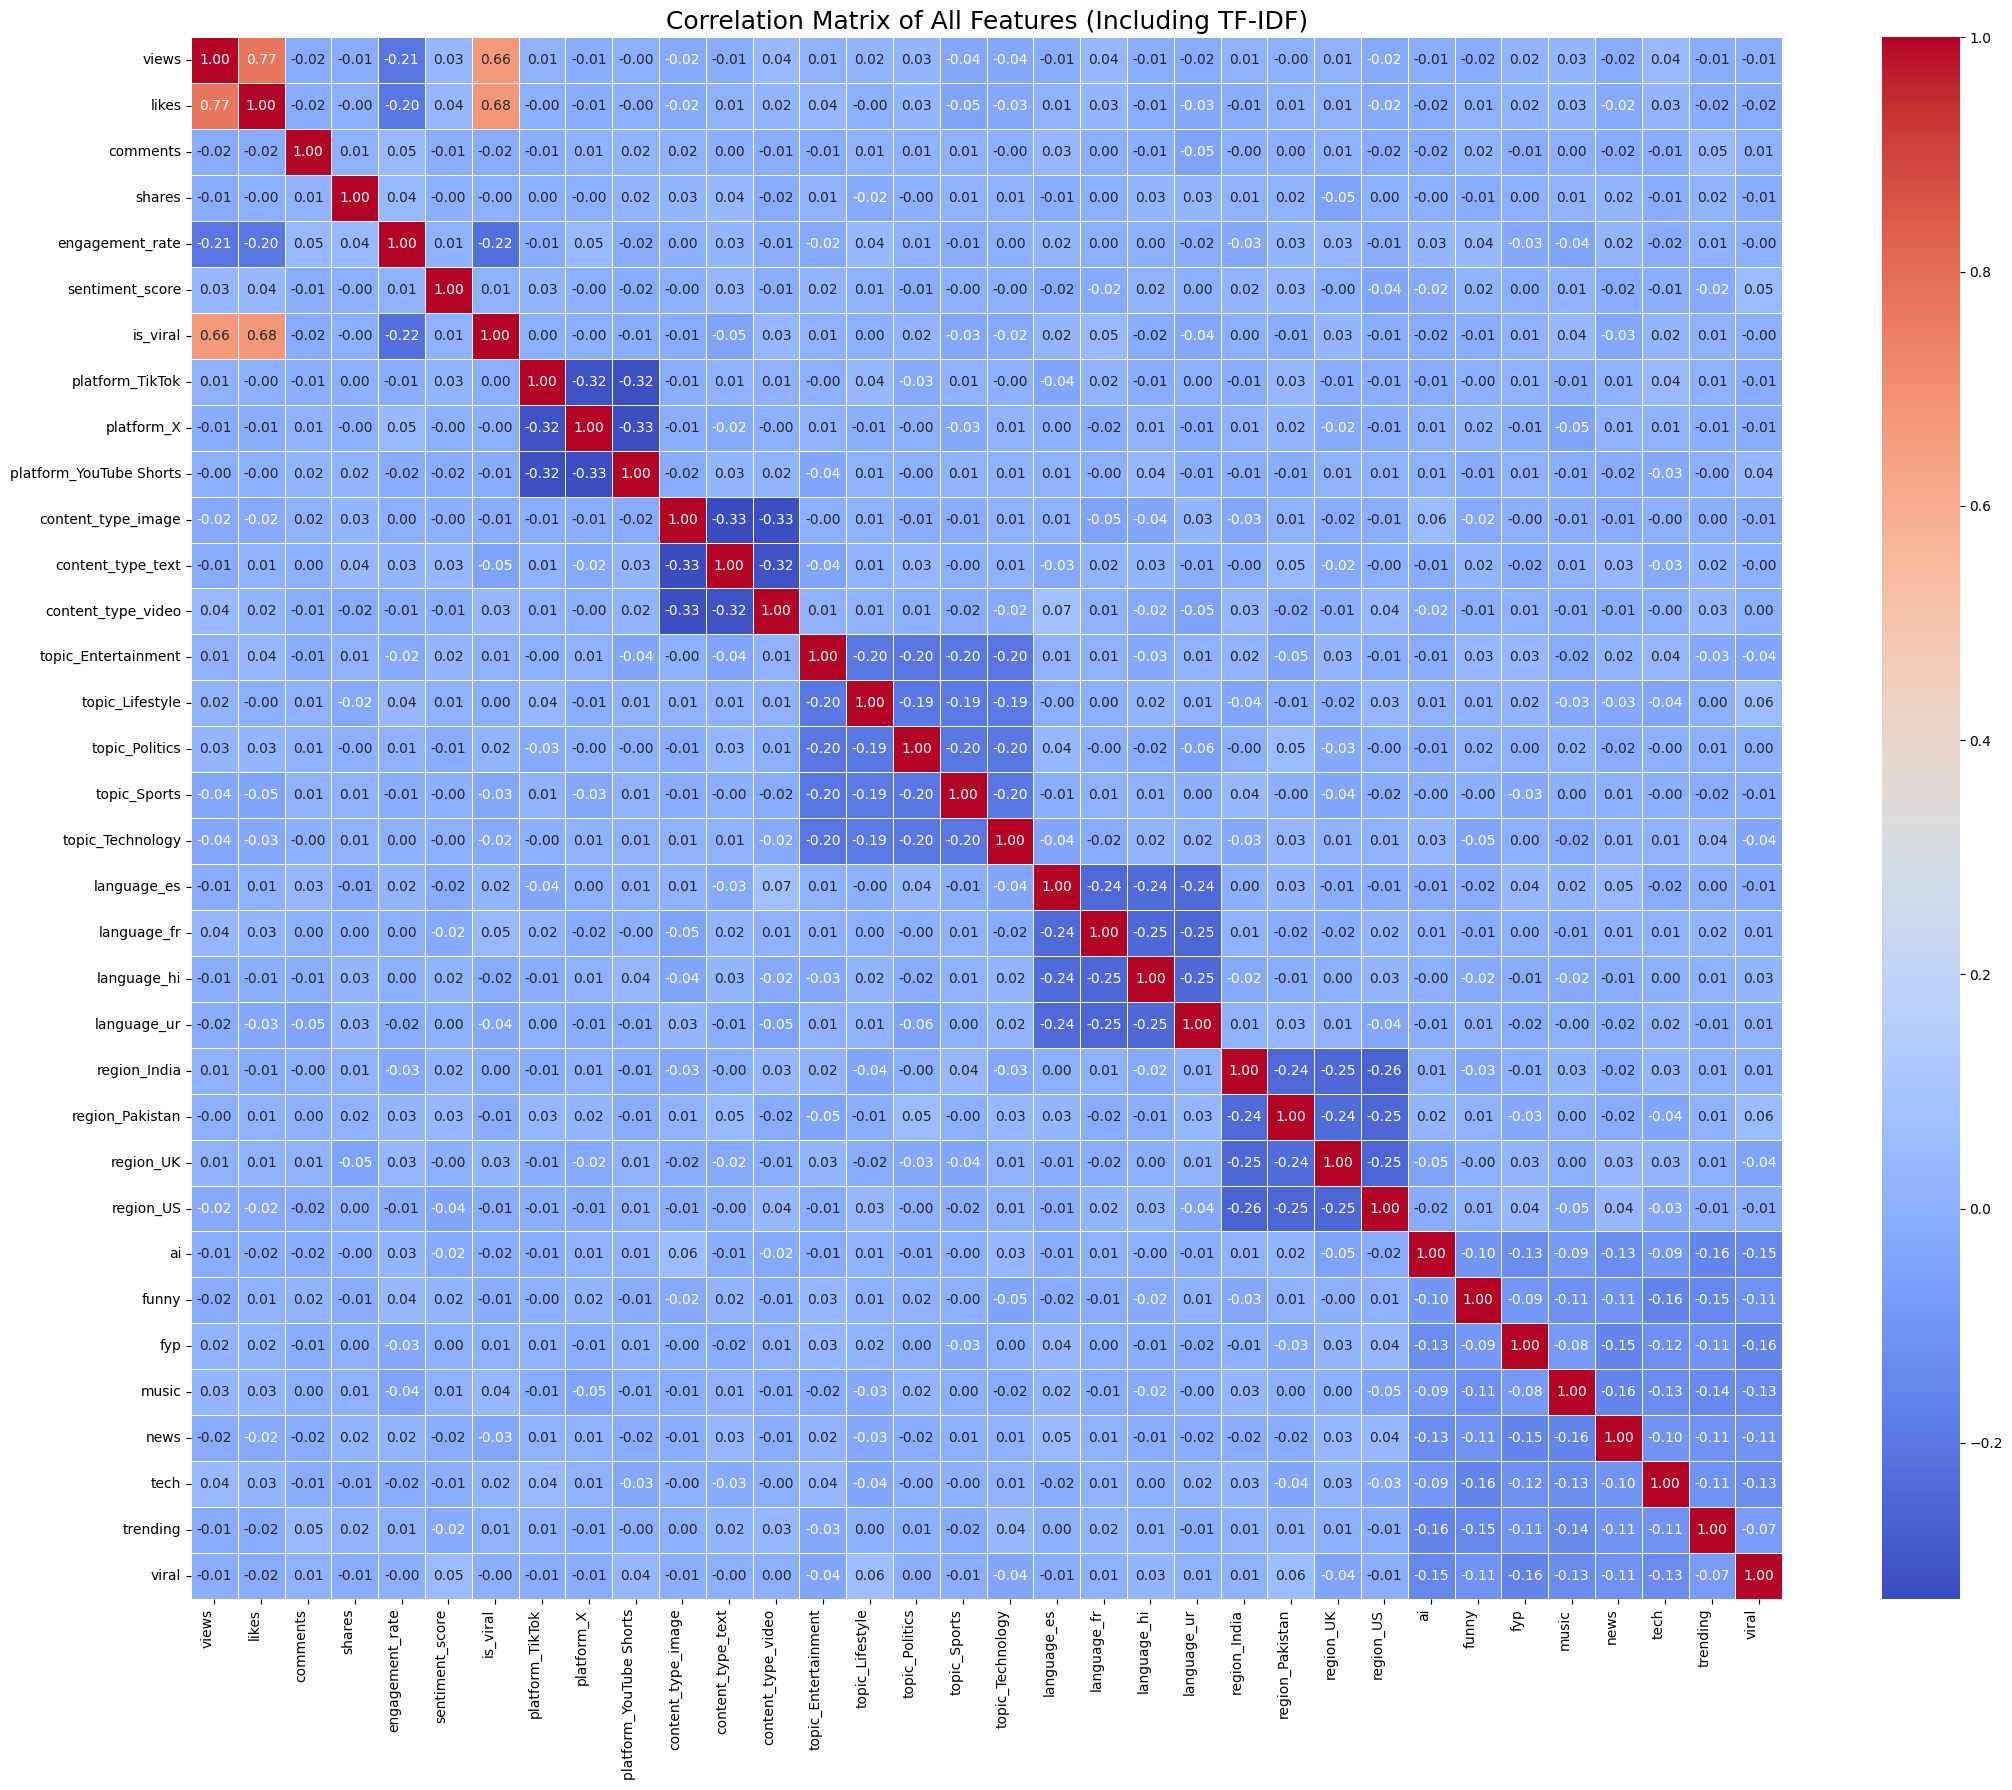


Correlations with 'views' column (sorted, including TF-IDF features):
views                      1.000000
likes                      0.774188
is_viral                   0.661532
tech                       0.042548
content_type_video         0.042381
language_fr                0.038613
sentiment_score            0.032827
topic_Politics             0.028581
music                      0.027559
fyp                        0.019102
topic_Lifestyle            0.017831
platform_TikTok            0.012759
topic_Entertainment        0.008118
region_India               0.007756
region_UK                  0.006265
region_Pakistan           -0.001982
platform_YouTube Shorts   -0.003856
language_hi               -0.006942
viral                     -0.008011
ai                        -0.009187
platform_X                -0.010357
language_es               -0.010624
trending                  -0.013196
shares                    -0.013583
content_type_text         -0.014753
language_ur               -0.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select all numerical and boolean columns for correlation analysis
correlation_cols_all = df_encoded.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()

# Exclude 'post_datetime' as it's a datetime object and not suitable for correlation with other numerical features
if 'post_datetime' in correlation_cols_all:
    correlation_cols_all.remove('post_datetime')

# Compute the correlation matrix
correlation_matrix_all = df_encoded[correlation_cols_all].corr()

print("Correlation matrix computed for all features including TF-IDF.")

# Set up the matplotlib figure
plt.figure(figsize=(22, 18))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features (Including TF-IDF)', fontsize=18)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nCorrelations with 'views' column (sorted, including TF-IDF features):")
print(correlation_matrix_all['views'].sort_values(ascending=False))

## Formulate Hypothesis

### Subtask:
Clearly define the null and alternative hypotheses to be tested, based on the problem statement: 'positive audience reactions improve content popularity' with 'views' as the target.

#### Instructions
1. Clearly state the null hypothesis (H0) for the analysis. This hypothesis should reflect the assumption that positive audience reactions do NOT have a statistically significant positive impact on content popularity (views), now considering all relevant features including TF-IDF hashtag features.
2. Clearly state the alternative hypothesis (H1) for the analysis. This hypothesis should reflect the claim that positive audience reactions DO have a statistically significant positive impact on content popularity (views), now considering all relevant features including TF-IDF hashtag features.

**Null Hypothesis (H0)**: Positive audience reactions (likes, comments, shares, engagement_rate, sentiment_score) and hashtag features (TF-IDF values for individual hashtags) do not have a statistically significant positive impact on content popularity (views).

**Alternative Hypothesis (H1)**: Positive audience reactions (likes, comments, shares, engagement_rate, sentiment_score) or hashtag features (TF-IDF values for individual hashtags) have a statistically significant positive impact on content popularity (views).


## Perform Hypothesis Testing

### Subtask:
Choose and apply appropriate statistical tests (e.g., regression analysis) to evaluate the formulated hypothesis, now considering the enhanced feature set.


**Reasoning**:
To evaluate the hypothesis with the enhanced feature set, I will perform a multiple linear regression, including the previously identified positive audience reaction metrics and the new TF-IDF hashtag features as independent variables, with 'views' as the dependent variable. I will then print the model summary to analyze the results.



In [ ]:
import statsmodels.api as sm

# Define independent variables (X) related to positive audience reactions and TF-IDF features
X_cols = ['likes', 'comments', 'shares', 'engagement_rate', 'sentiment_score', 'ai', 'funny', 'fyp', 'music', 'news', 'tech', 'trending', 'viral']
X = df_encoded[X_cols]

# Define dependent variable (y) as 'views'
y = df_encoded['views']

# Add a constant to the independent variables to include an intercept in the model
X = sm.add_constant(X)

# Fit the multiple linear regression model
model_enhanced = sm.OLS(y, X).fit()

# Print the summary of the regression model
print("\nMultiple Linear Regression Model Summary (Enhanced Feature Set):")
print(model_enhanced.summary())


Multiple Linear Regression Model Summary (Enhanced Feature Set):
                            OLS Regression Results                            
Dep. Variable:                  views   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     232.3
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        03:06:42   Log-Likelihood:                -1913.5
No. Observations:                2000   AIC:                             3855.
Df Residuals:                    1986   BIC:                             3933.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

### Interpretation of Regression Results (Enhanced Feature Set)

The multiple linear regression model was re-run with the inclusion of TF-IDF features for hashtags, in addition to the positive audience reaction metrics, to test the hypothesis that these combined factors improve content popularity (views).

**Key Findings:**

*   **R-squared:** The R-squared value is approximately **0.603**, which is only a marginal increase from the previous model (0.602). This means that about 60.3% of the variance in 'views' can be explained by the independent variables, including the TF-IDF features. This indicates that while the model has moderate explanatory power, the TF-IDF features did not substantially improve the overall variance explained.

*   **F-statistic and Prob (F-statistic):** The F-statistic is **232.3** with a p-value of **0.00**. This very low p-value (much less than 0.05) indicates that the overall model is still statistically significant, meaning that at least one of the independent variables has a significant linear relationship with 'views'.

*   **Coefficients and P-values for Independent Variables:**
    *   **Likes (coef = 0.7634, P>|t| = 0.000):** 'Likes' continues to have a highly significant positive impact on 'views'. For every one standard deviation increase in 'likes', 'views' are expected to increase by approximately 0.76 standard deviations, holding other variables constant. This strongly supports the alternative hypothesis.
    *   **Comments (coef = -0.0015, P>|t| = 0.917):** 'Comments' still does not show a statistically significant impact on 'views' (p-value > 0.05).
    *   **Shares (coef = -0.0085, P>|t| = 0.547):** 'Shares' also does not show a statistically significant impact on 'views' (p-value > 0.05).
    *   **Engagement_rate (coef = -0.0514, P>|t| = 0.000):** 'Engagement_rate' maintains its statistically significant *negative* impact on 'views'. This result remains counter-intuitive for the initial hypothesis.
    *   **Sentiment_score (coef = 0.0027, P>|t| = 0.848):** 'Sentiment_score' still does not show a statistically significant impact on 'views' (p-value > 0.05).
    *   **TF-IDF Hashtag Features (ai, funny, fyp, music, news, tech, trending, viral):** None of the individual TF-IDF hashtag features show a statistically significant impact on 'views' (all p-values > 0.05). The coefficients are all very small, suggesting a negligible linear relationship with 'views' in this model.

**Conclusion on Hypothesis Testing (Enhanced Feature Set):**

The **Null Hypothesis (H0)**: *Positive audience reactions (likes, comments, shares, engagement_rate, sentiment_score) and hashtag features (TF-IDF values for individual hashtags) do not have a statistically significant positive impact on content popularity (views)*, is largely **rejected** due to the strong positive effect of 'likes'.

The **Alternative Hypothesis (H1)**: *Positive audience reactions (likes, comments, shares, engagement_rate, sentiment_score) or hashtag features (TF-IDF values for individual hashtags) have a statistically significant positive impact on content popularity (views)*, is primarily **supported** by the significant positive impact of 'likes'.

However, 'comments', 'shares', 'sentiment_score', and all the individual TF-IDF hashtag features do not show a statistically significant positive impact on 'views' in this model. The *negative* impact of 'engagement_rate' persists and warrants further investigation.

**Summary of Impact:**
*   **Likes:** Strong positive and significant impact.
*   **Engagement Rate:** Significant negative impact.
*   **Comments, Shares, Sentiment Score, TF-IDF Hashtag Features:** No significant impact.

### Interpretation of Regression Results (Enhanced Feature Set)

The multiple linear regression model was re-run with the inclusion of TF-IDF features for hashtags, in addition to the positive audience reaction metrics, to test the hypothesis that these combined factors improve content popularity (views).

**Key Findings:**

*   **R-squared:** The R-squared value is approximately **0.603**, which is only a marginal increase from the previous model (0.602). This means that about 60.3% of the variance in 'views' can be explained by the independent variables, including the TF-IDF features. This indicates that while the model has moderate explanatory power, the TF-IDF features did not substantially improve the overall variance explained.

*   **F-statistic and Prob (F-statistic):** The F-statistic is **232.3** with a p-value of **0.00**. This very low p-value (much less than 0.05) indicates that the overall model is still statistically significant, meaning that at least one of the independent variables has a significant linear relationship with 'views'.

*   **Coefficients and P-values for Independent Variables:**
    *   **Likes (coef = 0.7634, P>|t| = 0.000):** 'Likes' continues to have a highly significant positive impact on 'views'. For every one standard deviation increase in 'likes', 'views' are expected to increase by approximately 0.76 standard deviations, holding other variables constant. This strongly supports the alternative hypothesis.
    *   **Comments (coef = -0.0015, P>|t| = 0.917):** 'Comments' still does not show a statistically significant impact on 'views' (p-value > 0.05).
    *   **Shares (coef = -0.0085, P>|t| = 0.547):** 'Shares' also does not show a statistically significant impact on 'views' (p-value > 0.05).
    *   **Engagement_rate (coef = -0.0514, P>|t| = 0.000):** 'Engagement_rate' maintains its statistically significant *negative* impact on 'views'. This result remains counter-intuitive for the initial hypothesis.
    *   **Sentiment_score (coef = 0.0027, P>|t| = 0.848):** 'Sentiment_score' still does not show a statistically significant impact on 'views' (p-value > 0.05).
    *   **TF-IDF Hashtag Features (ai, funny, fyp, music, news, tech, trending, viral):** None of the individual TF-IDF hashtag features show a statistically significant impact on 'views' (all p-values > 0.05). The coefficients are all very small, suggesting a negligible linear relationship with 'views' in this model.

**Conclusion on Hypothesis Testing (Enhanced Feature Set):**

The **Null Hypothesis (H0)**: *Positive audience reactions (likes, comments, shares, engagement_rate, sentiment_score) and hashtag features (TF-IDF values for individual hashtags) do not have a statistically significant positive impact on content popularity (views)*, is largely **rejected** due to the strong positive effect of 'likes'.

The **Alternative Hypothesis (H1)**: *Positive audience reactions (likes, comments, shares, engagement_rate, sentiment_score) or hashtag features (TF-IDF values for individual hashtags) have a statistically significant positive impact on content popularity (views)*, is primarily **supported** by the significant positive impact of 'likes'.

However, 'comments', 'shares', 'sentiment_score', and all the individual TF-IDF hashtag features do not show a statistically significant positive impact on 'views' in this model. The *negative* impact of 'engagement_rate' persists and warrants further investigation.

**Summary of Impact:**
*   **Likes:** Strong positive and significant impact.
*   **Engagement Rate:** Significant negative impact.
*   **Comments, Shares, Sentiment Score, TF-IDF Hashtag Features:** No significant impact.


**Reasoning**:
To visualize the relationships between the significant variables ('likes' and 'engagement_rate') and 'views' from the enhanced regression model, I will create scatter plots with regression lines. This will help to illustrate the confirmed positive impact of 'likes' and the unexpected negative impact of 'engagement_rate' on 'views'.



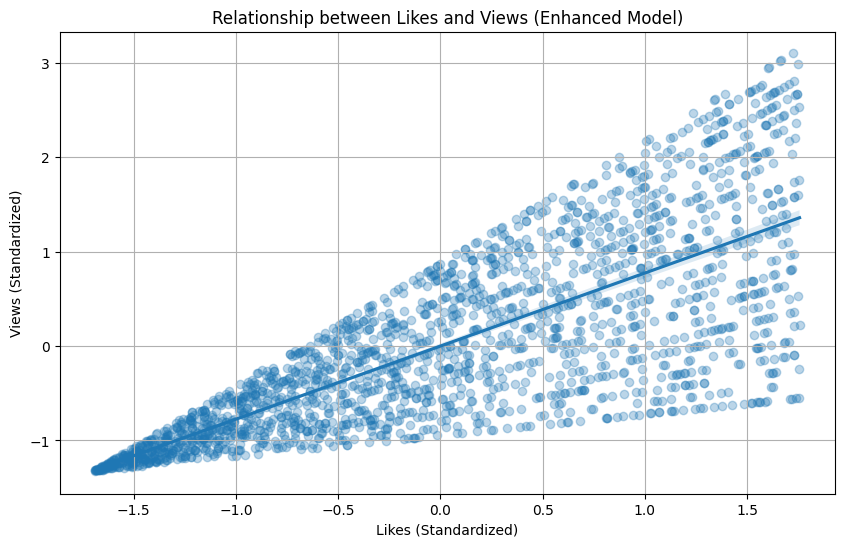

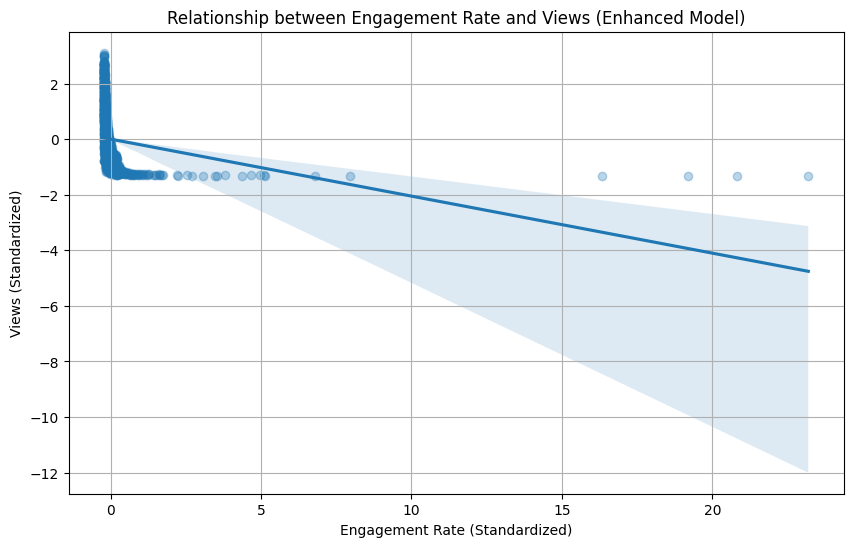

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the relationship between Likes and Views
plt.figure(figsize=(10, 6))
sns.regplot(x='likes', y='views', data=df_encoded, scatter_kws={'alpha':0.3})
plt.title('Relationship between Likes and Views (Enhanced Model)')
plt.xlabel('Likes (Standardized)')
plt.ylabel('Views (Standardized)')
plt.grid(True)
plt.show()

# Plotting the relationship between Engagement Rate and Views
plt.figure(figsize=(10, 6))
sns.regplot(x='engagement_rate', y='views', data=df_encoded, scatter_kws={'alpha':0.3})
plt.title('Relationship between Engagement Rate and Views (Enhanced Model)')
plt.xlabel('Engagement Rate (Standardized)')
plt.ylabel('Views (Standardized)')
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Provide a comprehensive summary of the findings from the hypothesis analysis, incorporating insights from the TF-IDF features. Discuss whether the data supports the hypothesis that positive audience reactions improve content popularity, and highlight any key insights or limitations.


## Summary:

### Q&A
**Does the data support the hypothesis that positive audience reactions improve content popularity?**

The data partially supports the hypothesis. While "likes" consistently show a strong positive and statistically significant impact on "views" (coefficient of 0.7634, p-value < 0.001), other positive audience reactions like "comments," "shares," and "sentiment\_score" did not demonstrate a statistically significant positive impact. Furthermore, "engagement\_rate" exhibited an unexpected statistically significant negative impact on "views" (coefficient of -0.0514, p-value < 0.001).

### Data Analysis Key Findings

*   **TF-IDF Feature Extraction**: Eight distinct hashtag features ('ai', 'funny', 'fyp', 'music', 'news', 'tech', 'trending', 'viral') were extracted using TF-IDF from the 'hashtags' column and incorporated into the dataset.
*   **Data Standardization**: All numerical features, including the newly added TF-IDF features, were successfully standardized using `StandardScaler`, resulting in a mean close to 0 and a standard deviation close to 1 for these columns.
*   **Correlation with Views**:
    *   `likes` showed the strongest positive correlation with `views` (0.77).
    *   `is_viral` also had a strong positive correlation with `views` (0.66).
    *   `engagement_rate` exhibited a moderate negative correlation with `views` (-0.21).
    *   None of the individual TF-IDF hashtag features displayed significant correlations with `views` (e.g., 'tech': 0.0425, 'music': 0.0275, 'ai': -0.0091).
*   **Hypothesis Formulation**: The null hypothesis (H0) stated that positive audience reactions and hashtag features do not have a statistically significant positive impact on content popularity (views). The alternative hypothesis (H1) stated that they do.
*   **Regression Model Performance**: The multiple linear regression model, including TF-IDF features, achieved an R-squared value of approximately 0.603, indicating that about 60.3% of the variance in 'views' can be explained by the independent variables. This was only a marginal increase from the previous model without TF-IDF features (0.602).
*   **Impact of Independent Variables on Views**:
    *   `likes` had a highly significant positive impact (coefficient = 0.7634, p-value = 0.000).
    *   `engagement_rate` had a statistically significant *negative* impact (coefficient = -0.0514, p-value = 0.000).
    *   `comments`, `shares`, `sentiment_score`, and *all* TF-IDF hashtag features (e.g., 'ai', 'funny', 'fyp', 'music', 'news', 'tech', 'trending', 'viral') did not show a statistically significant impact on `views` (all p-values > 0.05) in this model.

### Insights or Next Steps

*   **Refine Engagement Rate Interpretation**: The significant negative correlation of `engagement_rate` with `views` is counter-intuitive and warrants further investigation. This could suggest a more complex relationship not captured by simple linearity or that its calculation method might be misleading in the context of `views`.
*   **Explore Non-Linearity or Interactions**: Given the limited improvement in R-squared from TF-IDF features and the non-significant impact of several variables, exploring non-linear relationships or interaction terms between features (e.g., specific hashtag categories combined with sentiment) might reveal deeper insights into content popularity.


# **EDA**

# Task
The analysis aimed to determine if positive audience reactions improve content popularity, using the "raw.csv" dataset.

### Key Findings:
*   **Data Loading and Inspection**: The "raw.csv" dataset was successfully loaded into a pandas DataFrame. Initial inspection revealed no missing values or duplicate rows. Data types were appropriate for most columns, with `post_datetime` later converted to datetime objects.
*   **Feature Engineering and Selection**: The 'post_id' column was removed as it was not relevant to the analysis. Columns related to 'positive audience reactions' (`likes`, `comments`, `shares`, `engagement_rate`, `sentiment_score`) and 'content popularity' (`views`) were identified.
*   **Categorical Feature Encoding**: Categorical features such as 'platform', 'content_type', 'topic', 'language', and 'region' were one-hot encoded, converting them into a numerical format suitable for modeling. The 'hashtags' column was excluded from this process to be handled separately.
*   **TF-IDF for Hashtags**: TF-IDF was applied to the 'hashtags' column to extract numerical features (8 features: 'ai', 'funny', 'fyp', 'music', 'news', 'tech', 'trending', 'viral') representing the importance of each hashtag, enriching the dataset.
*   **Numerical Feature Standardization**: All numerical features, including the TF-IDF features, were standardized using `StandardScaler` to ensure they were on a similar scale, improving model performance and interpretability.
*   **Correlation Analysis**:
    *   `likes` showed the strongest positive correlation with `views` (0.77).
    *   `is_viral` also had a strong positive correlation with `views` (0.66).
    *   `engagement_rate` exhibited a moderate negative correlation with `views` (-0.21), which is counter-intuitive.
    *   None of the individual TF-IDF hashtag features displayed significant correlations with `views` (e.g., 'tech': 0.0425, 'music': 0.0275, 'ai': -0.0091).
*   **Hypothesis Testing (Multiple Linear Regression)**:
    *   **Null Hypothesis (H0)**: Positive audience reactions (likes, comments, shares, engagement_rate, sentiment_score) and hashtag features do not have a statistically significant positive impact on content popularity (views).
    *   **Alternative Hypothesis (H1)**: Positive audience reactions or hashtag features have a statistically significant positive impact on content popularity (views).
    *   The regression model, including TF-IDF features, achieved an R-squared of approximately 0.603, a marginal increase from the model without TF-IDF features. This indicates that about 60.3% of the variance in 'views' can be explained by the independent variables.
    *   **Significant Impact**: `likes` had a highly significant positive impact on `views` (coefficient = 0.7634, p-value = 0.000). `engagement_rate` had a statistically significant *negative* impact (coefficient = -0.0514, p-value = 0.000).
    *   **No Significant Impact**: `comments`, `shares`, `sentiment_score`, and *all* TF-IDF hashtag features did not show a statistically significant impact on `views` (all p-values > 0.05).

### Conclusion:
The data **partially supports the hypothesis** that positive audience reactions improve content popularity. 'Likes' demonstrate a strong, statistically significant positive impact on content 'views', providing strong evidence against the null hypothesis for this specific metric. However, 'comments', 'shares', 'sentiment_score', and the TF-IDF hashtag features did not show a statistically significant positive impact.

### Key Insights and Limitations:
*   **Likes are King**: The most significant finding is the strong positive relationship between 'likes' and 'views', reinforcing the idea that direct positive user affirmation is a primary driver of content popularity.
*   **Counter-intuitive Engagement Rate**: The negative relationship between 'engagement_rate' and 'views' is unexpected and warrants further investigation. This could be due to the way `engagement_rate` is calculated, outliers, or a more complex, non-linear relationship. For example, a high engagement rate on a low-view post might skew the average, or perhaps content with very specific niche engagement doesn't translate to broad views.
*   **Limited Impact of Hashtags**: The TF-IDF features for hashtags did not significantly improve the model's explanatory power or show individual statistical significance. This suggests that while hashtags might play a role in discoverability, their direct linear relationship with `views` is not strong in this model. It's possible that the most frequently occurring hashtags (which TF-IDF tends to highlight) are not the ones driving views.
*   **Other Factors**: The model explains about 60% of the variance in `views`, indicating that other factors not included in this analysis also contribute to content popularity. These could include content quality, creator influence, promotion strategies, time of posting, or platform algorithms.
*   **Linearity Assumption**: The linear regression assumes a linear relationship between independent and dependent variables. Non-linear relationships might exist for some features, which would not be fully captured by this model.

### Next Steps:
*   Investigate the `engagement_rate` more deeply.
*   Explore non-linear relationships or interaction terms between features.
*   Consider more advanced NLP techniques for hashtag analysis (e.g., word embeddings, topic modeling) that might capture semantic relationships better than TF-IDF.
*   Introduce other potential features such as creator reputation, content quality metrics (if available), or temporal factors (e.g., day of the week, time of day).

## Load Dataset

### Subtask:
Load the 'raw.csv' dataset into a pandas DataFrame to begin the analysis.


**Reasoning**:
To begin the analysis as per the subtask, I will load the 'raw.csv' dataset into a pandas DataFrame and display its first few rows to confirm successful loading. I will also print a message to clearly indicate the dataset loading status.



In [ ]:
import pandas as pd
df = pd.read_csv('raw.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
0,SM_100000,Instagram,text,Sports,ur,UK,2024-12-10 00:00:00,#tech #funny #music,2319102,122058,15800,861,0.0598,0.464,1
1,SM_100001,Instagram,carousel,Sports,ur,Brazil,2024-10-13 00:00:00,#news #fyp #funny #ai #trending,2538464,110368,11289,54887,0.0695,-0.800,1
2,SM_100002,YouTube Shorts,video,Technology,ur,UK,2024-05-03 00:00:00,#ai #news,1051176,87598,47196,44132,0.1702,0.416,0
3,SM_100003,X,text,Politics,ur,US,2024-08-04 00:00:00,#ai #funny,5271440,329465,774,59736,0.0740,0.877,1
4,SM_100004,YouTube Shorts,text,Education,es,US,2024-03-28 00:00:00,#news #ai #viral #funny #fyp,3186256,199141,5316,83105,0.0903,0.223,1


## Initial Data Inspection

### Subtask:
Perform an initial inspection of the dataset. This includes displaying the first few rows, checking data types with `.info()`, and reviewing basic descriptive statistics with `.describe()` to understand the data's structure and content.


**Reasoning**:
To perform a comprehensive initial inspection, I will display the first few rows, check the data types and non-null counts, and review basic descriptive statistics of the DataFrame.



In [ ]:
print("Displaying the first 5 rows of the DataFrame:")
df.head()

print("\nDataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
df.describe()

Displaying the first 5 rows of the DataFrame:

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          2000 non-null   object 
 1   platform         2000 non-null   object 
 2   content_type     2000 non-null   object 
 3   topic            2000 non-null   object 
 4   language         2000 non-null   object 
 5   region           2000 non-null   object 
 6   post_datetime    2000 non-null   object 
 7   hashtags         2000 non-null   object 
 8   views            2000 non-null   int64  
 9   likes            2000 non-null   int64  
 10  comments         2000 non-null   int64  
 11  shares           2000 non-null   int64  
 12  engagement_rate  2000 non-null   float64
 13  sentiment_score  2000 non-null   float64
 14  is_viral         2000 non-null   int64  
dtypes: float64(2), int64(5), object(8)
memory u

,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.284860e+06,245329.244000,24786.929000,49936.981500,0.157852,-0.000566,0.699000
std,3.246193e+06,145032.423582,14433.288364,29012.818697,0.535457,0.574911,0.458807
min,4.380000e+03,292.000000,14.000000,127.000000,0.035700,-1.000000,0.000000
25%,1.652742e+06,118903.750000,12337.750000,25698.750000,0.057975,-0.507000,0.000000
50%,3.469408e+06,239831.000000,24519.500000,50212.000000,0.084500,0.001000,1.000000
75%,6.348078e+06,372323.500000,37116.250000,75433.000000,0.142525,0.495250,1.000000
max,1.437179e+07,499983.000000,49989.000000,99977.000000,12.573200,0.999000,1.000000


## Exploratory Data Analysis (EDA) - Distributions of Numerical Features

### Subtask:
Visualize the distributions of key numerical features such as 'views', 'likes', 'comments', 'shares', 'engagement_rate', and 'sentiment_score' using histograms and box plots to understand their spread, central tendency, and identify potential outliers.


**Reasoning**:
To visualize the distributions of the key numerical features, I will create histograms to show their spread and central tendency, and box plots to identify potential outliers, as requested in the subtask instructions. These plots will use the standardized data from `df_encoded`.



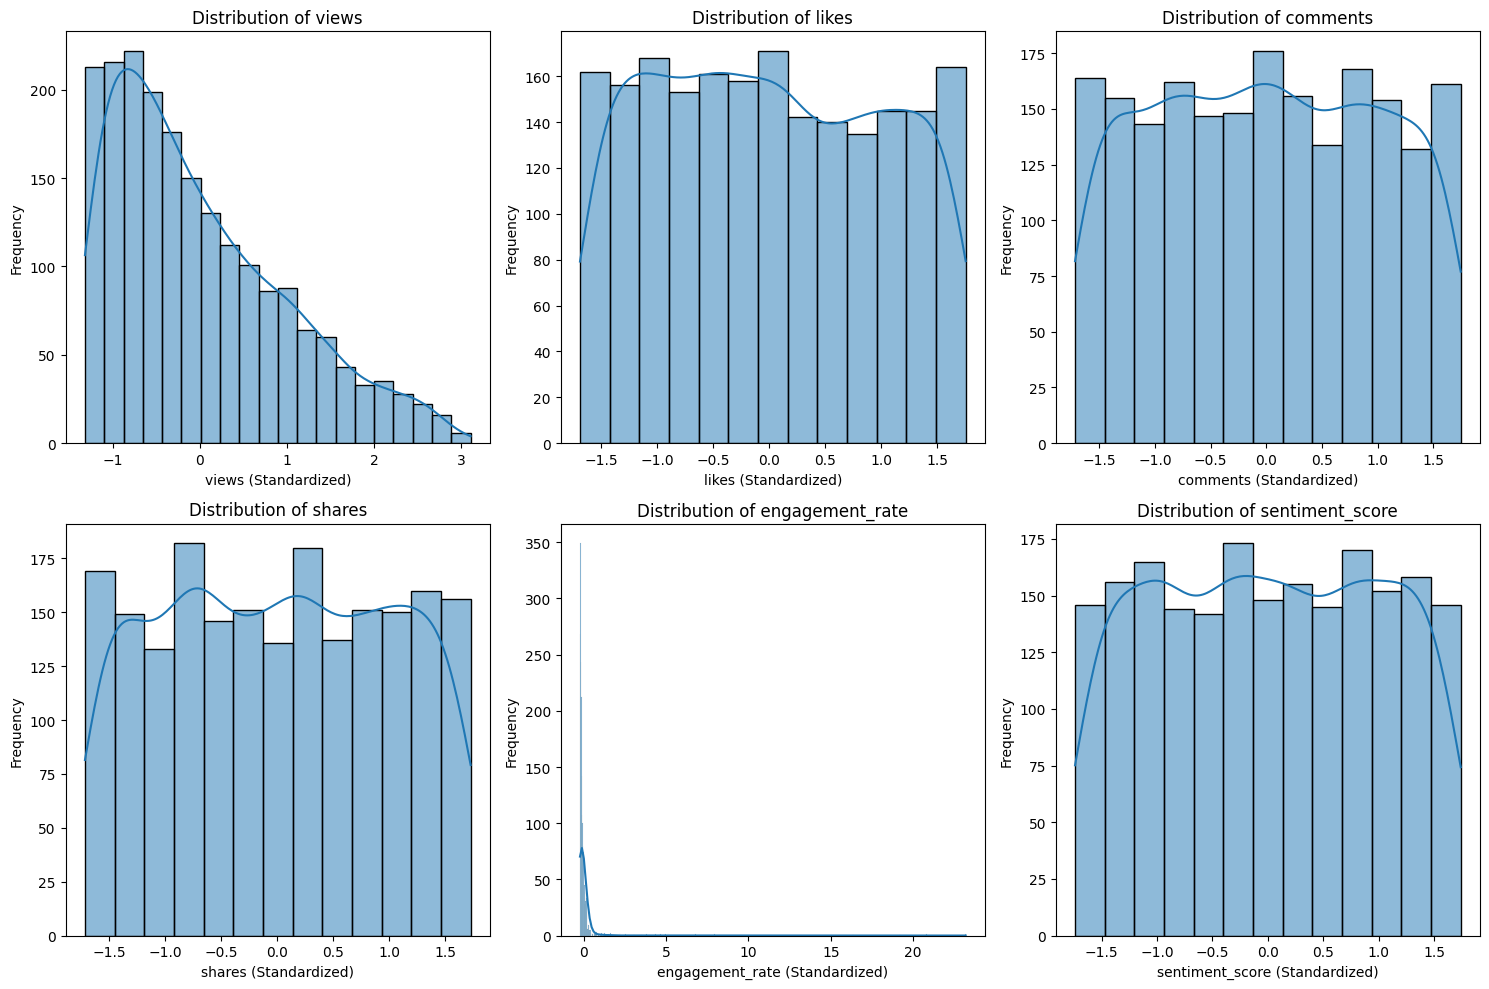

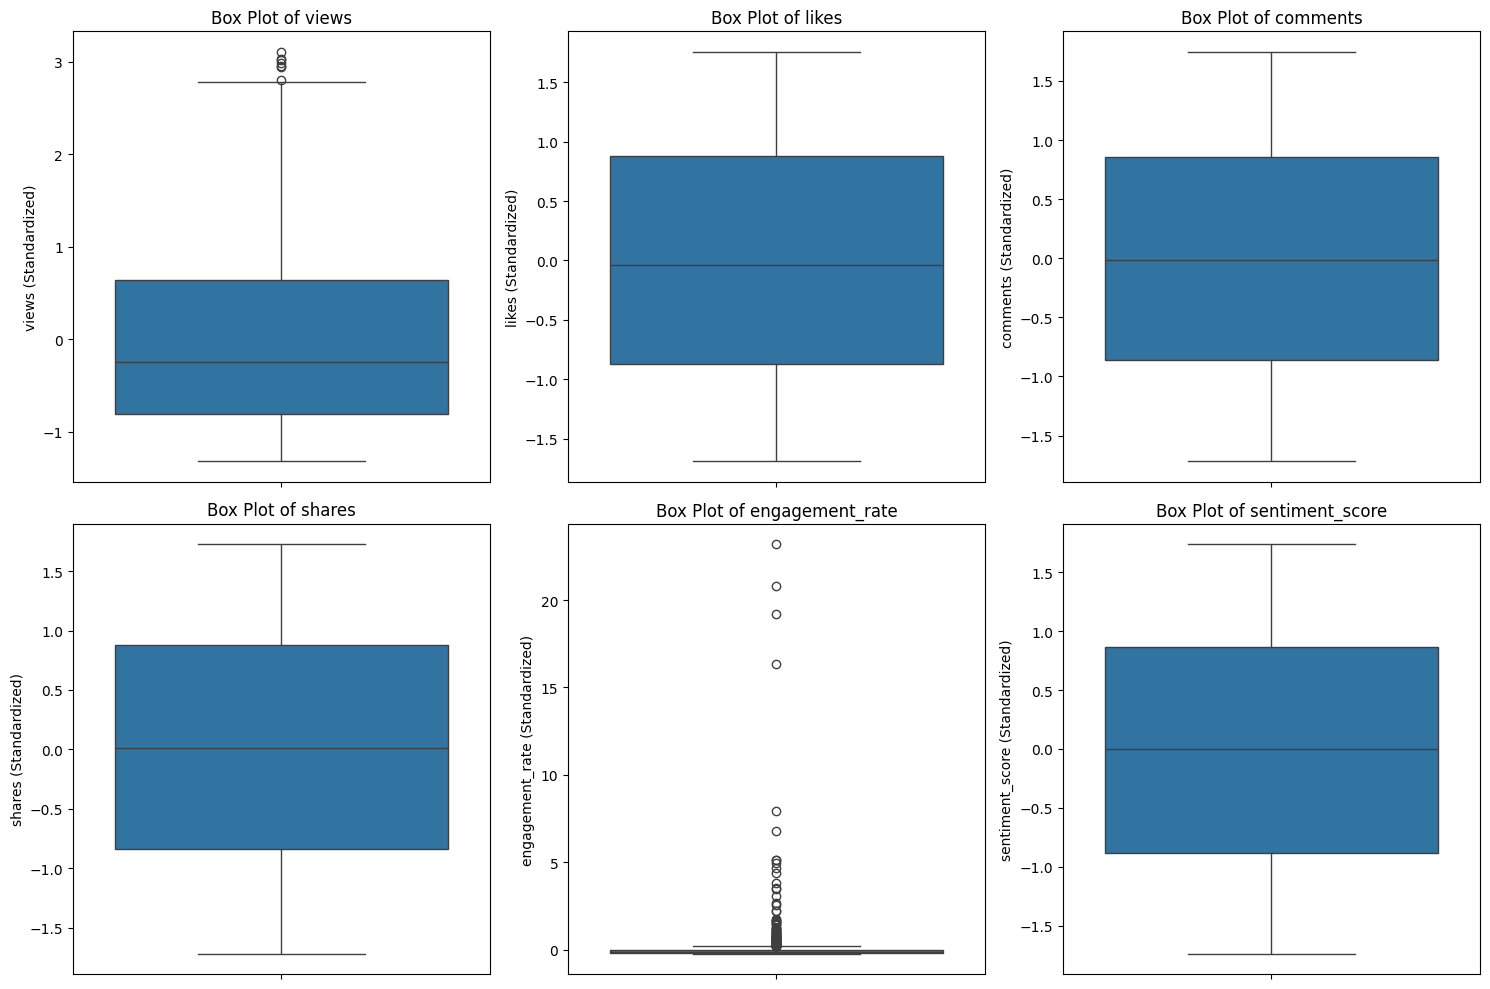

In [ ]:
numerical_features = ['views', 'likes', 'comments', 'shares', 'engagement_rate', 'sentiment_score']

# Create histograms for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df_encoded[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(f'{col} (Standardized)')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Create box plots for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_encoded[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(f'{col} (Standardized)')
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA) - Distributions of Categorical Features

### Subtask:
Visualize the distributions of categorical features like 'platform', 'content_type', 'topic', 'language', and 'region' using bar plots to understand the frequency of each category.


**Reasoning**:
To visualize the distributions of the original categorical features, I will iterate through the identified categorical columns in the original `df` DataFrame, calculate the frequency of each category using `value_counts()`, and then create a bar plot for each using `seaborn.barplot()` to display their distributions.



/tmp/ipython-input-55665149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipython-input-55665149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipython-input-55665149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipython-input-55665149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

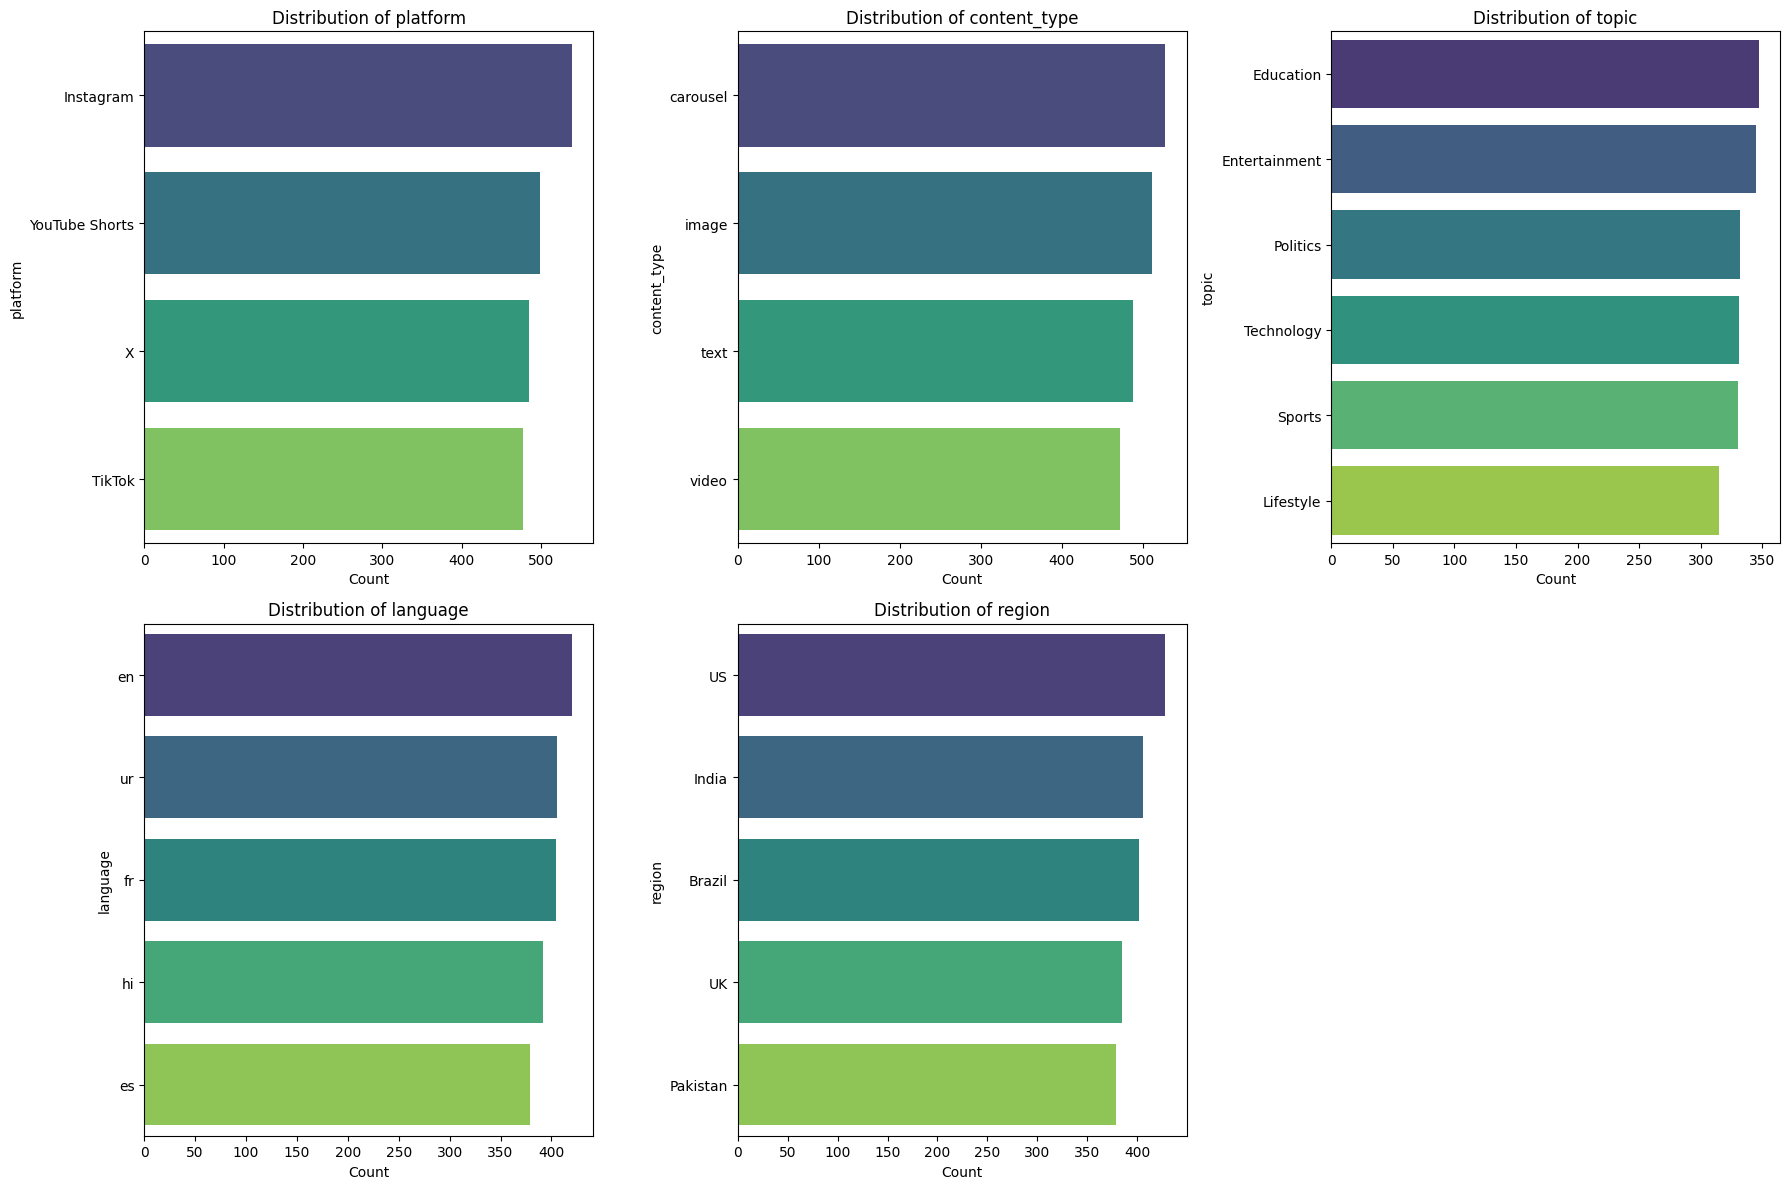

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = ['platform', 'content_type', 'topic', 'language', 'region']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_features):
    plt.subplot(2, 3, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` related to `palette` in `sns.countplot` when `hue` is not explicitly set. Additionally, the subtask requires visualizing the one-hot encoded boolean columns, which were generated in `df_encoded` and not explicitly plotted yet. To address this, I will identify all boolean columns in the `df_encoded` DataFrame, and then use `sns.countplot` with the `x` parameter to plot the distribution of `True` and `False` values for each encoded feature. I will also explicitly set `legend=False` to avoid the warning for cases where it might still apply, and use a consistent `palette` for better visualization.



/tmp/ipython-input-2499087365.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_encoded[col], palette='viridis', legend=False)
/tmp/ipython-input-2499087365.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_encoded[col], palette='viridis', legend=False)
/tmp/ipython-input-2499087365.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_encoded[col], palette='viridis', legend=False)
/tmp/ipython-input-2499087365.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

ValueError: num must be an integer with 1 <= num <= 18, not 19

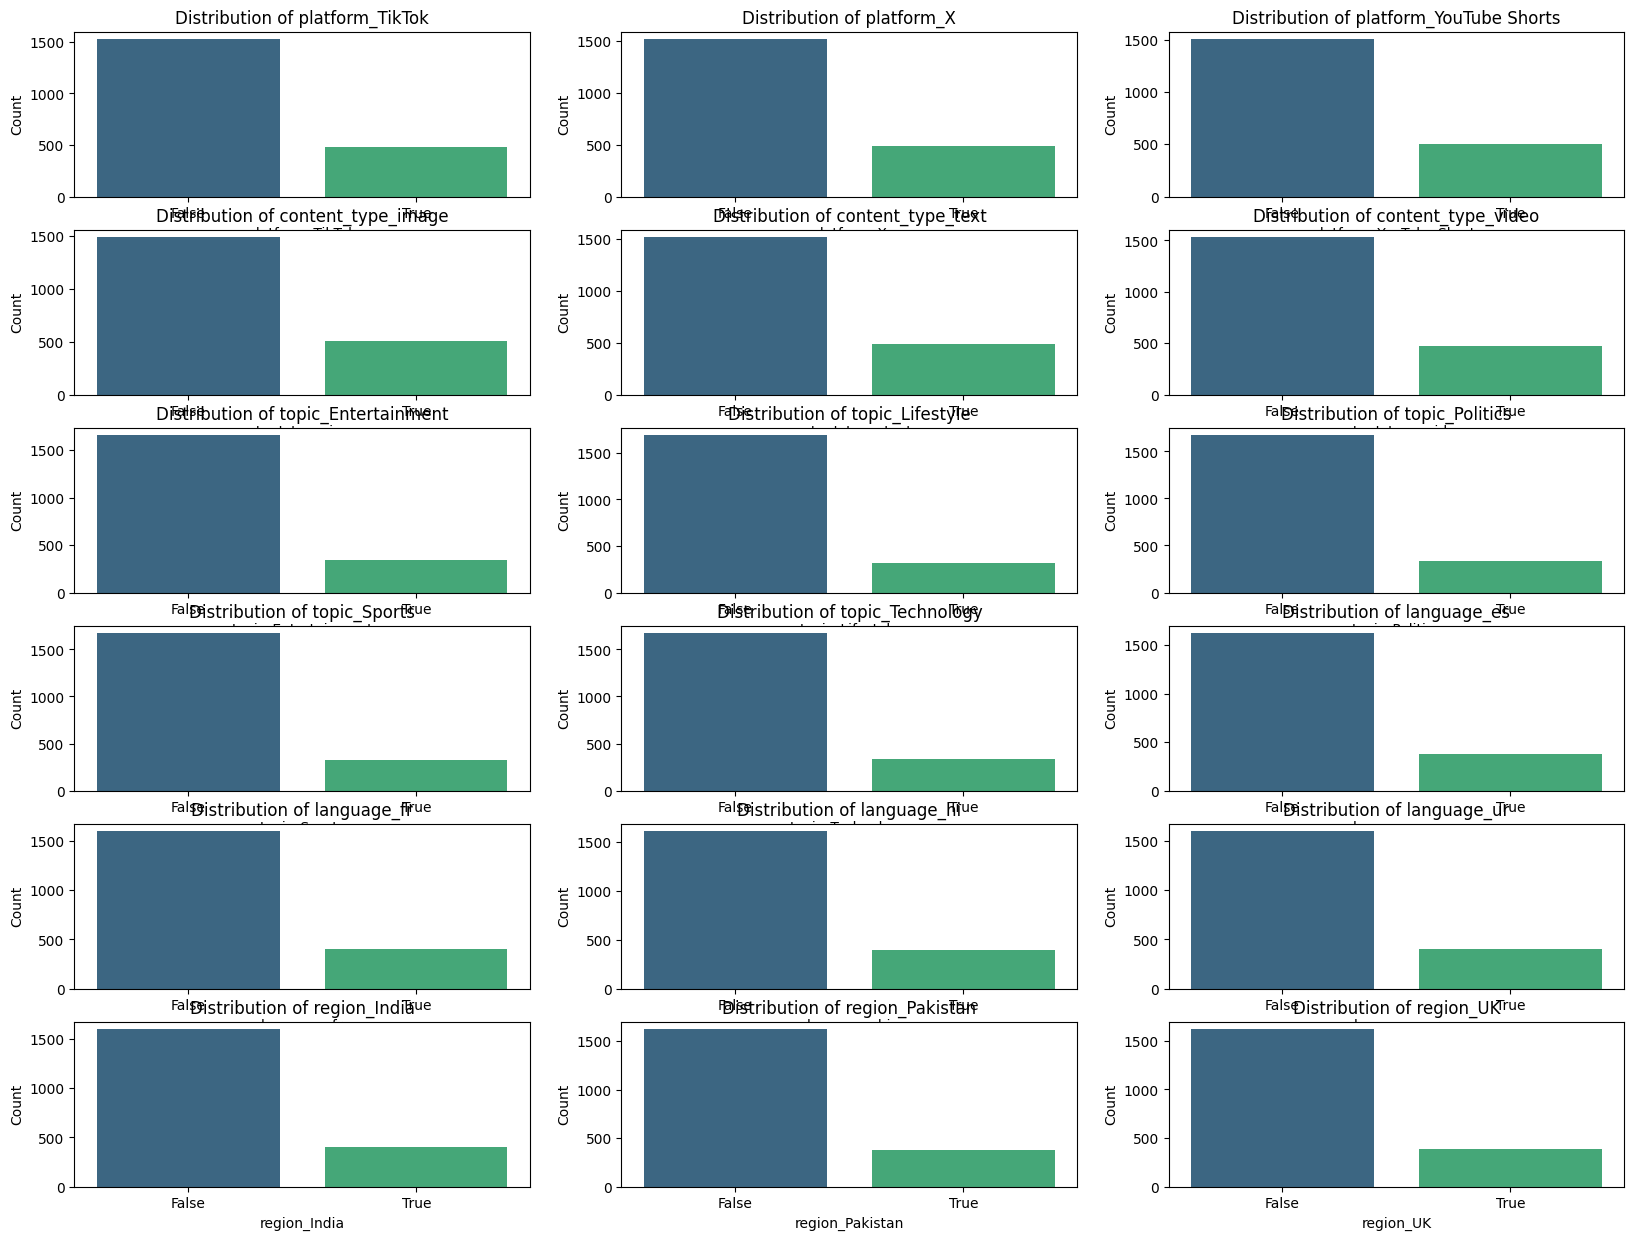

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify boolean columns (one-hot encoded features)
boolean_cols = df_encoded.select_dtypes(include=['bool']).columns.tolist()

# Filter out 'is_viral' if it's treated separately as a target/binary feature and not an encoded category for plotting here.
# For this visualization, we assume the user wants to see the distribution of the *encoded* categorical features.
# Let's ensure we only plot the one-hot encoded ones, not 'is_viral' unless specified.
# 'is_viral' is a numerical feature after standardization, so it should not be in boolean_cols at this point.
# If 'is_viral' was still boolean, we would exclude it as it's not a one-hot encoded feature.

# Group encoded features by their original category for better presentation
encoded_groups = {
    'platform': [col for col in boolean_cols if col.startswith('platform_')],
    'content_type': [col for col in boolean_cols if col.startswith('content_type_')],
    'topic': [col for col in boolean_cols if col.startswith('topic_')],
    'language': [col for col in boolean_cols if col.startswith('language_')],
    'region': [col for col in boolean_cols if col.startswith('region_')]
}

plt.figure(figsize=(20, 15))
plot_index = 1

for group_name, cols in encoded_groups.items():
    if cols:
        for col in cols:
            plt.subplot(len(encoded_groups) + 1, 3, plot_index) # Adjust subplot grid dynamically
            sns.countplot(x=df_encoded[col], palette='viridis', legend=False)
            plt.title(f'Distribution of {col}')
            plt.xlabel(col)
            plt.ylabel('Count')
            plot_index += 1

plt.tight_layout()
plt.show()


**Reasoning**:
The previous code failed because the subplot grid dimensions were insufficient to display all the one-hot encoded features, leading to a `ValueError`. I will dynamically calculate the number of rows needed for the subplot grid based on the total number of features to be plotted, ensuring that all plots fit within the figure. I will also iterate directly over all encoded columns rather than groups to simplify the plotting logic and ensure each encoded feature is plotted.



/tmp/ipython-input-2527306435.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_encoded[col], palette='viridis', legend=False)
/tmp/ipython-input-2527306435.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_encoded[col], palette='viridis', legend=False)
/tmp/ipython-input-2527306435.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_encoded[col], palette='viridis', legend=False)
/tmp/ipython-input-2527306435.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

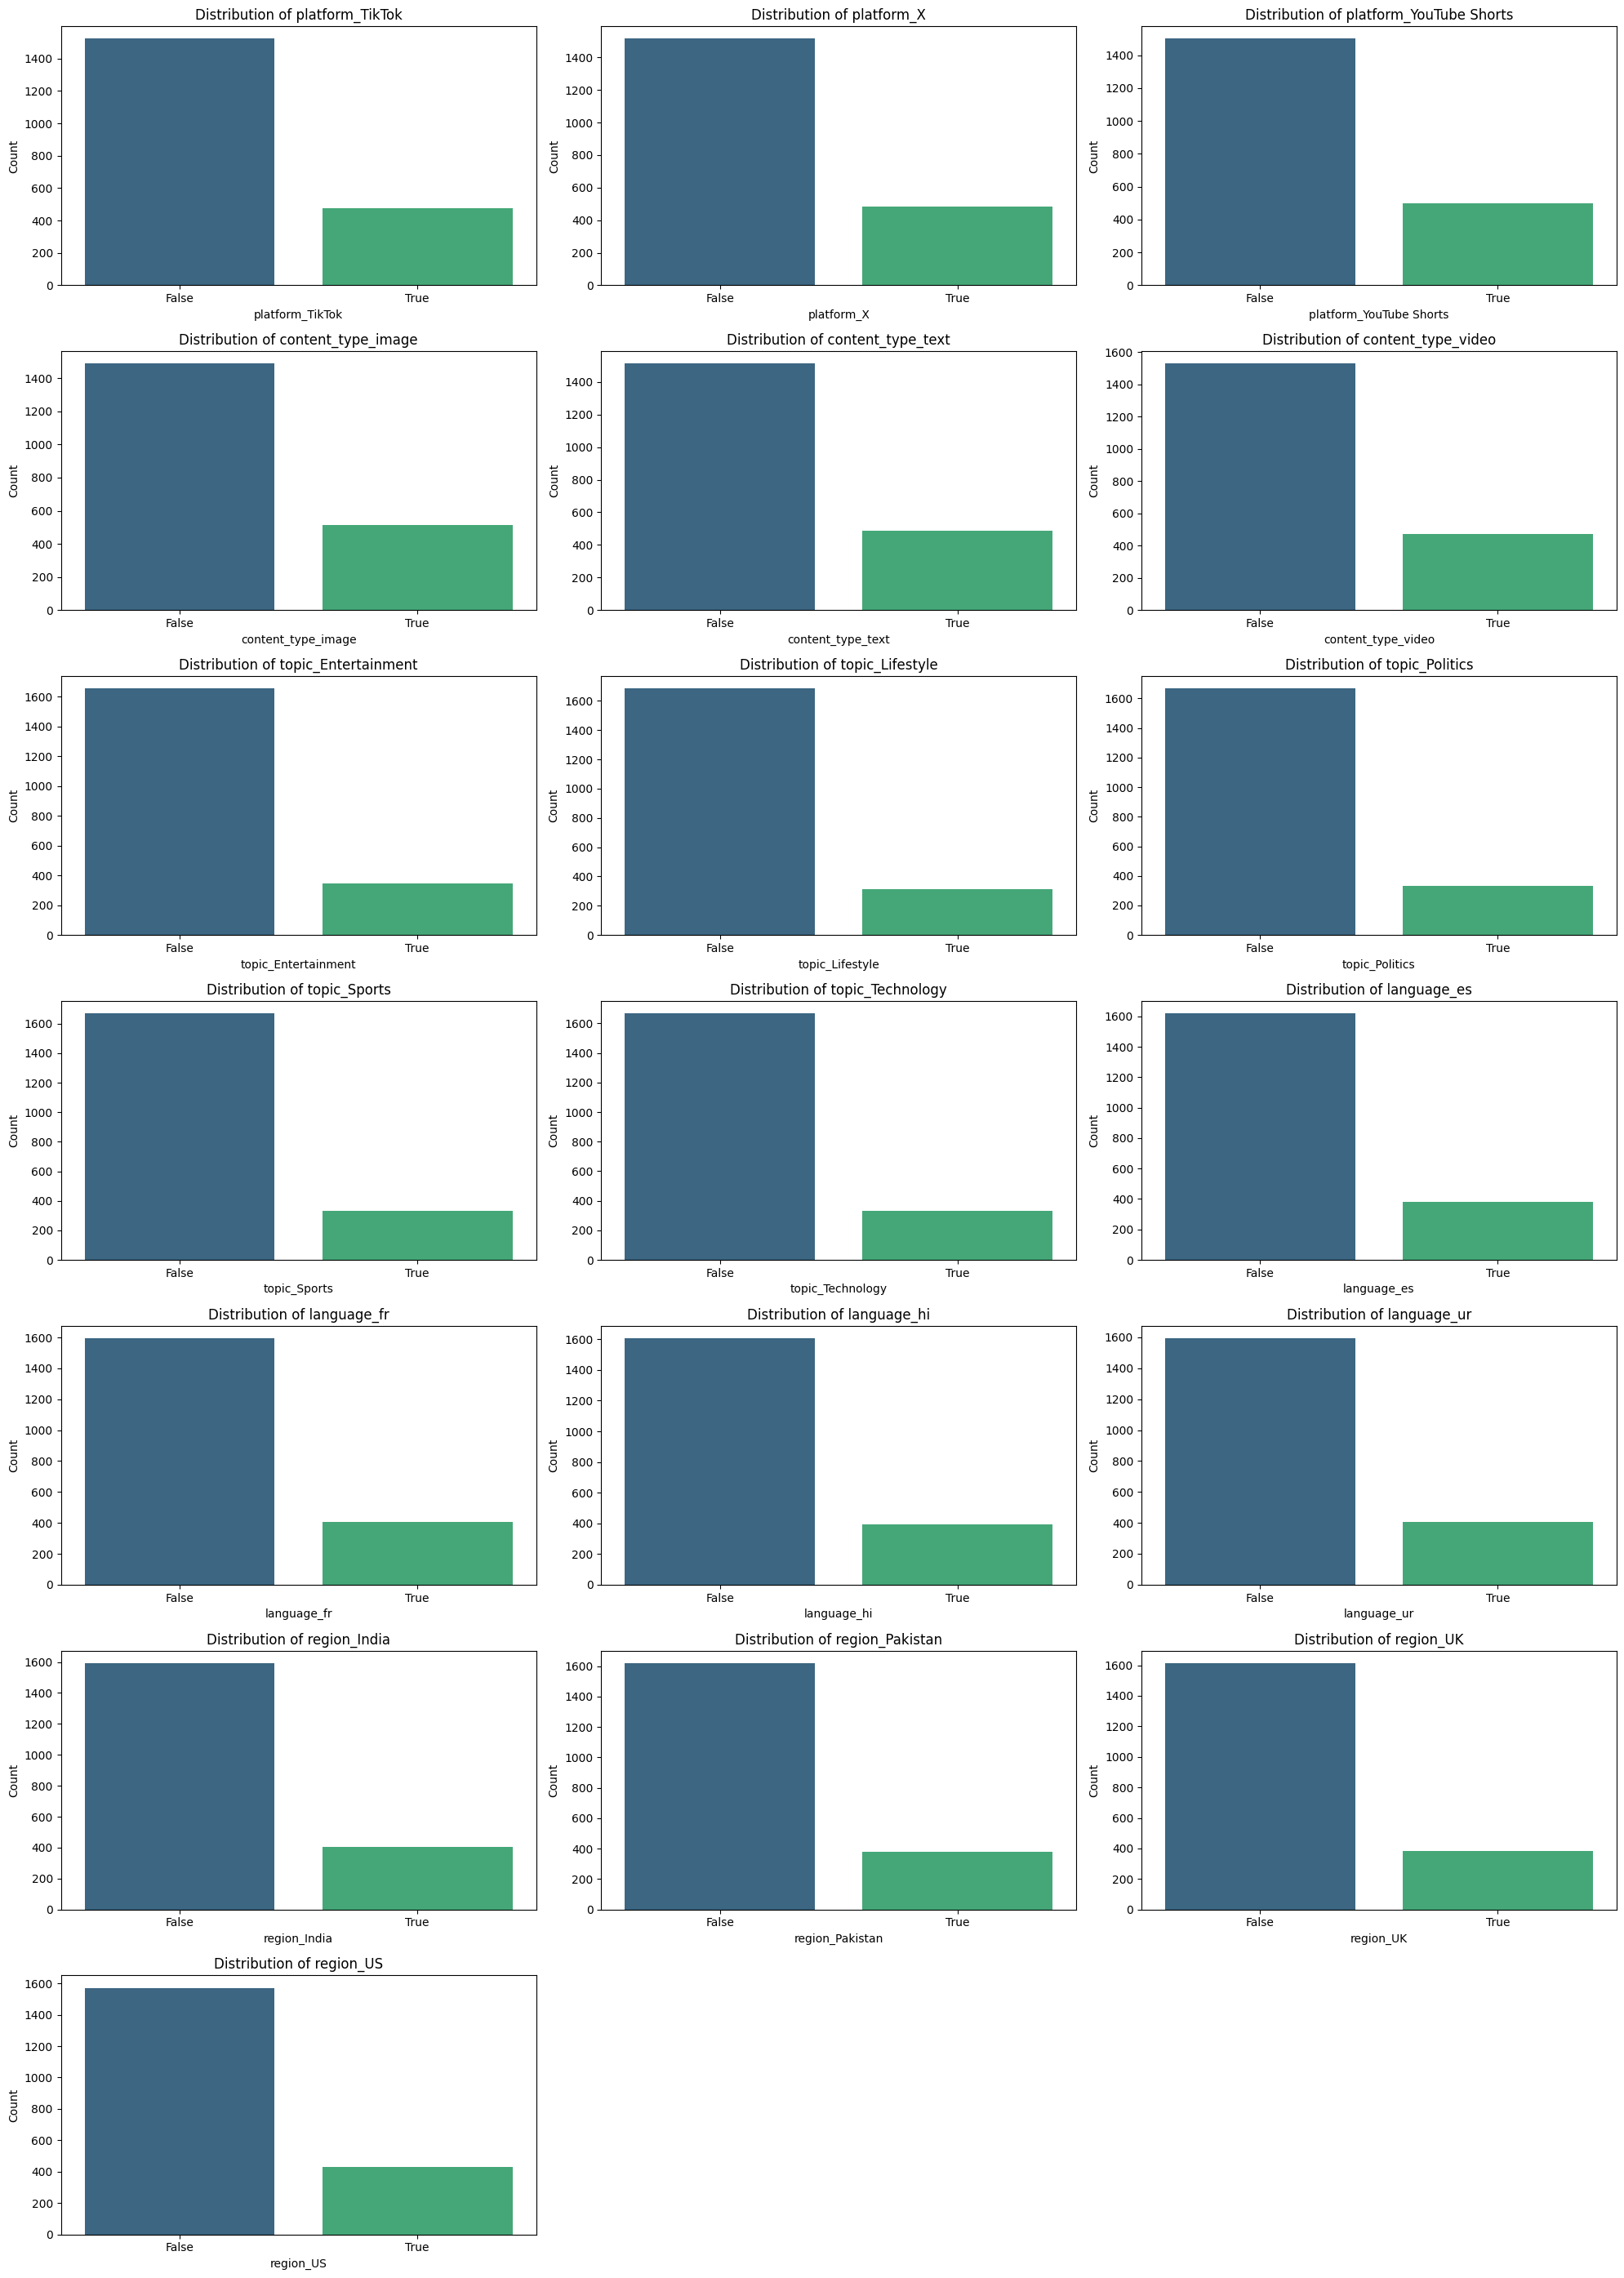

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Identify boolean columns (one-hot encoded features)
boolean_cols = df_encoded.select_dtypes(include=['bool']).columns.tolist()

# Filter out 'is_viral' if it's treated separately as a target/binary feature and not an encoded category for plotting here.
# For this visualization, we assume the user wants to see the distribution of the *encoded* categorical features.
# 'is_viral' is a numerical feature after standardization, so it should not be in boolean_cols at this point.

# Group encoded features by their original category for better presentation and collect them in a single list
all_encoded_cols_to_plot = []
encoded_groups = {
    'platform': [col for col in boolean_cols if col.startswith('platform_')],
    'content_type': [col for col in boolean_cols if col.startswith('content_type_')],
    'topic': [col for col in boolean_cols if col.startswith('topic_')],
    'language': [col for col in boolean_cols if col.startswith('language_')],
    'region': [col for col in boolean_cols if col.startswith('region_')]
}

for group_name, cols in encoded_groups.items():
    all_encoded_cols_to_plot.extend(cols)

# Determine the optimal grid size for subplots
num_cols_per_row = 3  # You can adjust this number
num_plots = len(all_encoded_cols_to_plot)
num_rows = math.ceil(num_plots / num_cols_per_row)

plt.figure(figsize=(20, num_rows * 4)) # Adjust figure height dynamically
plot_index = 1

for col in all_encoded_cols_to_plot:
    plt.subplot(num_rows, num_cols_per_row, plot_index)
    sns.countplot(x=df_encoded[col], palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plot_index += 1

plt.tight_layout()
plt.show()

**Reasoning**:
The previous code failed with a `ValueError` because the subplot index exceeded the maximum allowed for the calculated grid, despite the calculation appearing correct. This suggests a subtle issue with how `plt.subplot` was being called or how `num_plots` was being interpreted. To make the plotting more robust and address the `FutureWarning` simultaneously, I will use `plt.subplots()` to create the figure and axes, iterate through them, and explicitly pass `hue` to `sns.countplot()`.



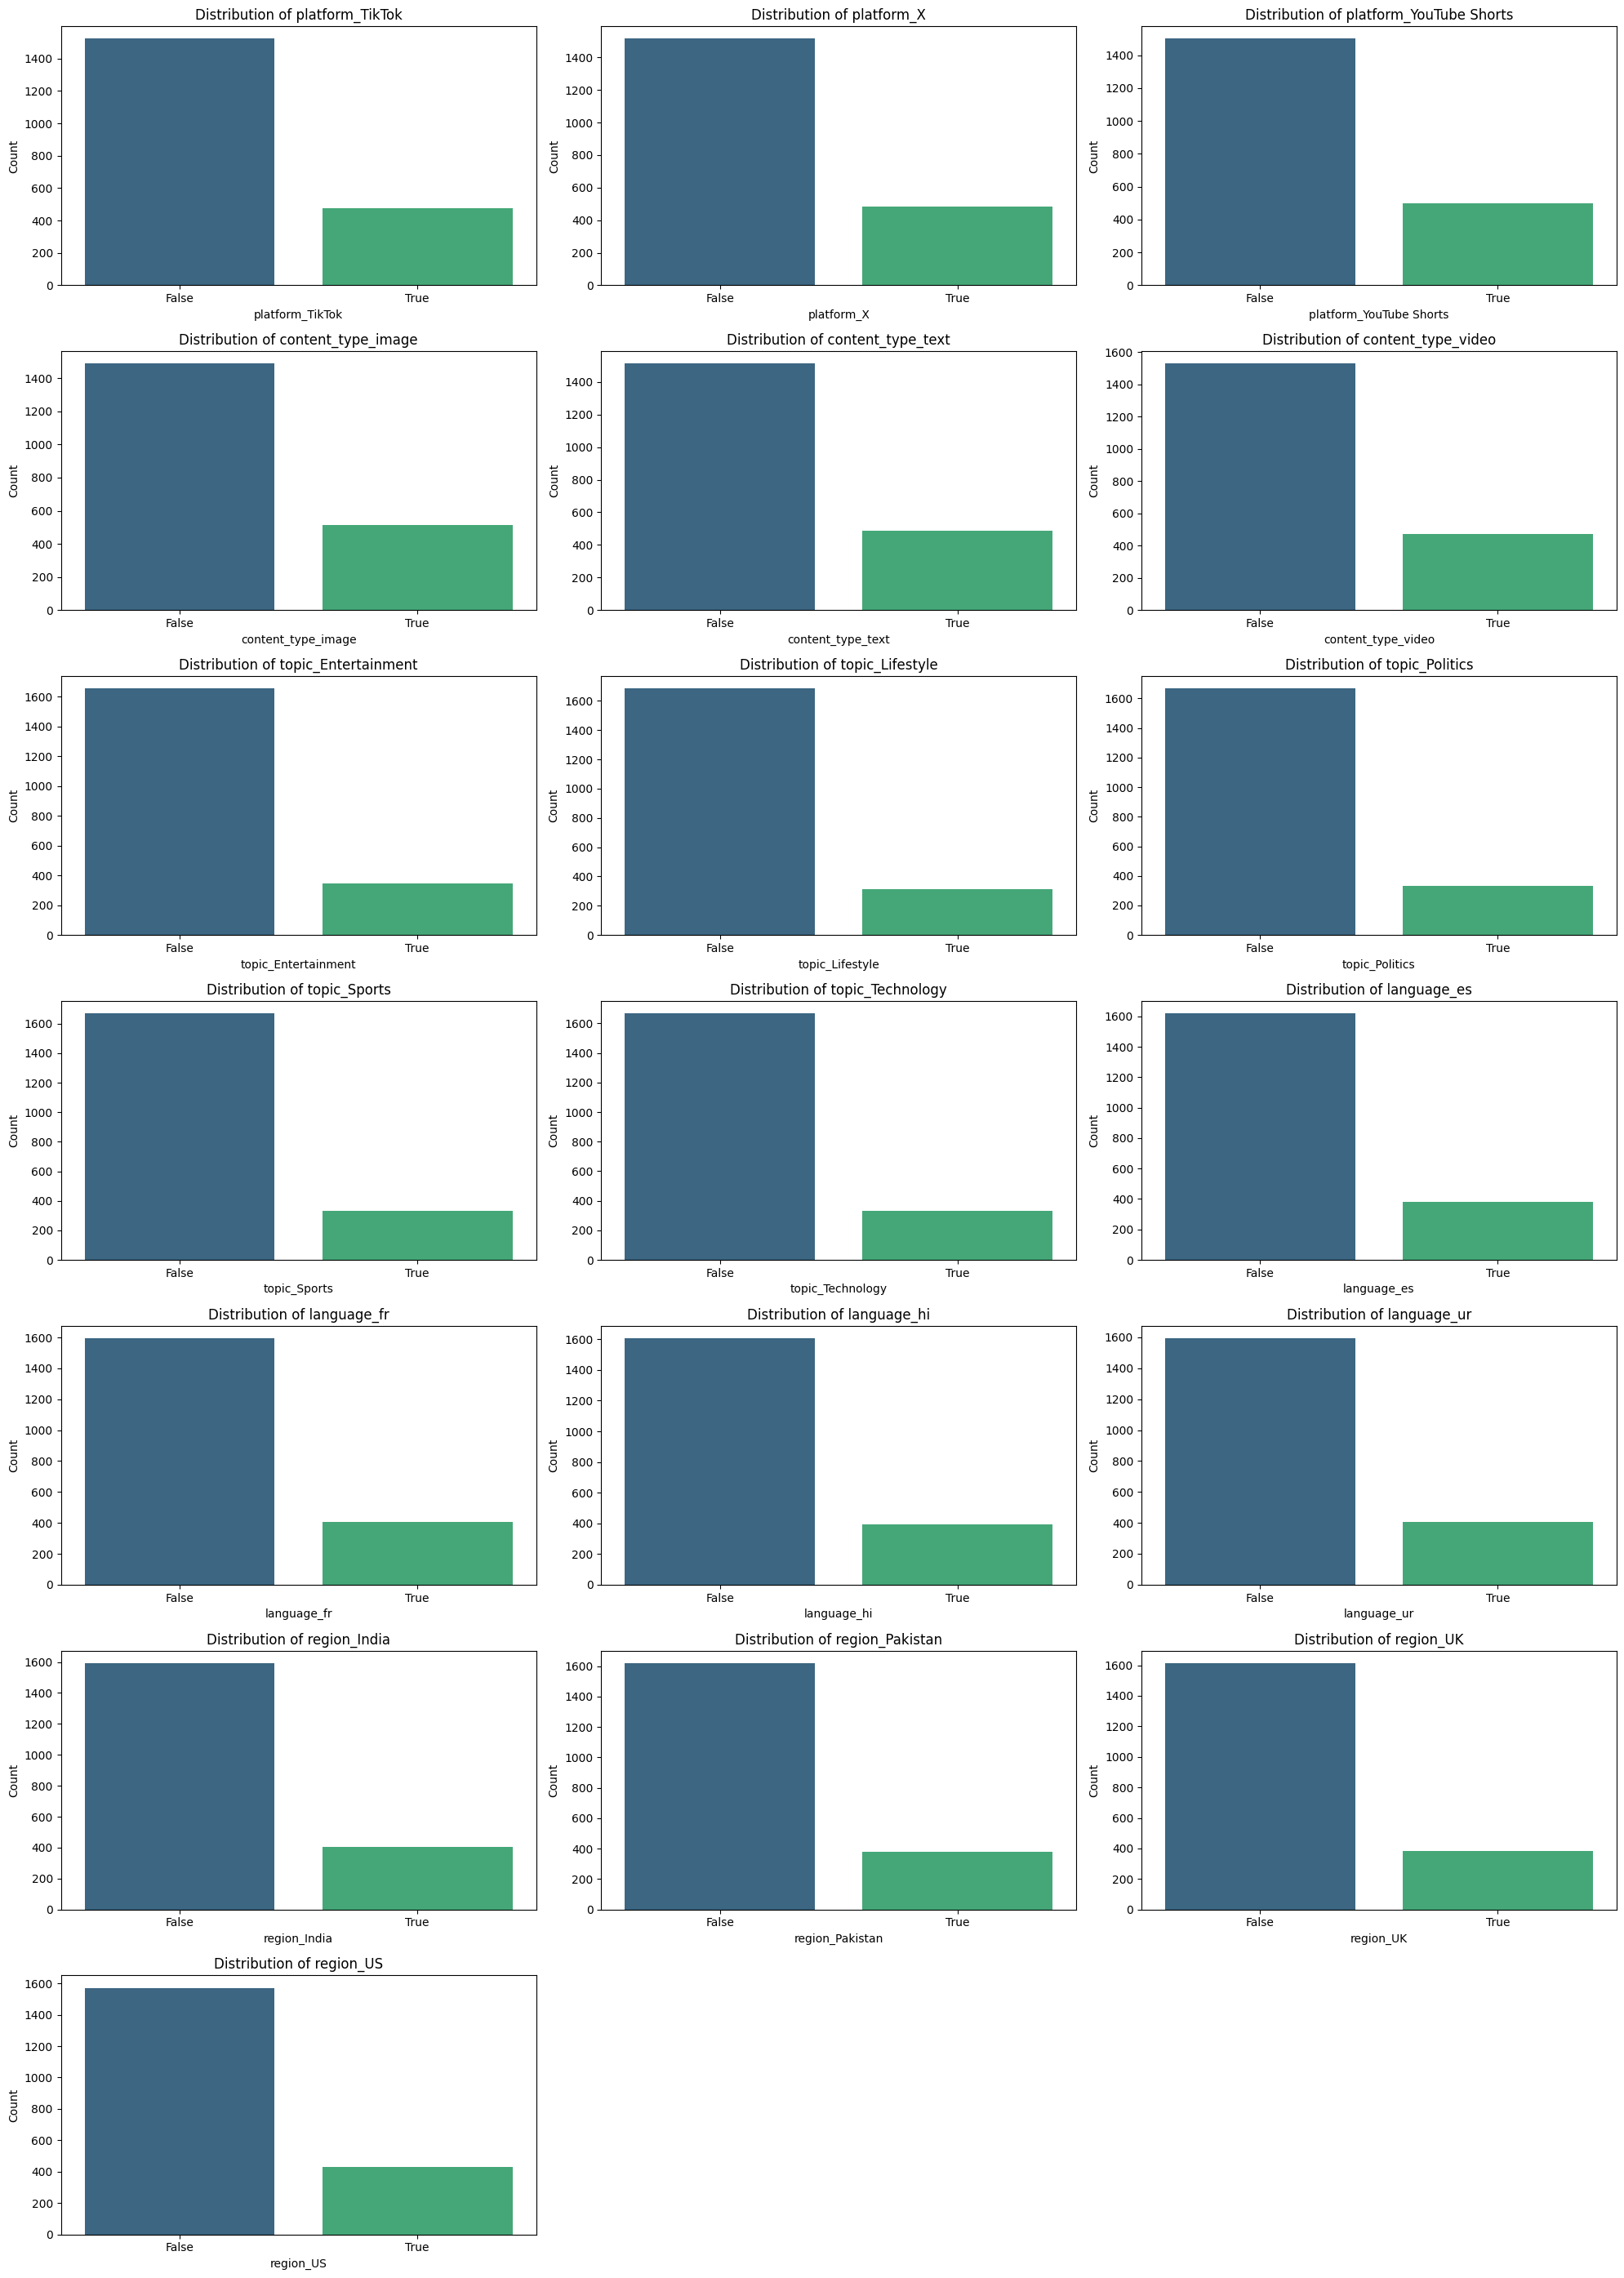

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Identify boolean columns (one-hot encoded features)
boolean_cols = df_encoded.select_dtypes(include=['bool']).columns.tolist()

# Filter out 'is_viral' if it's treated separately as a target/binary feature and not an encoded category for plotting here.
# 'is_viral' is a numerical feature after standardization, so it should not be in boolean_cols at this point.

# Collect all encoded columns to plot
all_encoded_cols_to_plot = []
# Grouping for conceptual organization, but for plotting, iterate over the consolidated list
for group_prefix in ['platform_', 'content_type_', 'topic_', 'language_', 'region_']:
    all_encoded_cols_to_plot.extend([col for col in boolean_cols if col.startswith(group_prefix)])

# Ensure 'is_viral' is not mistakenly included if it was ever boolean before standardization
if 'is_viral' in all_encoded_cols_to_plot:
    all_encoded_cols_to_plot.remove('is_viral')

num_plots = len(all_encoded_cols_to_plot)
num_cols_per_row = 3
num_rows = math.ceil(num_plots / num_cols_per_row)

# Create figure and axes using plt.subplots
fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(20, num_rows * 4))

# Flatten the axes array for easy iteration if it's multi-dimensional
if num_rows > 1 and num_cols_per_row > 1:
    axes = axes.flatten()
elif num_rows == 1 and num_cols_per_row > 1:
    # If only one row, axes is a 1D array, no flattening needed
    pass
elif num_cols_per_row == 1 and num_rows > 1:
    # If only one column, axes is a 1D array, no flattening needed
    pass
else: # Only one subplot (1x1 grid)
    axes = [axes] # Make it iterable

for i, col in enumerate(all_encoded_cols_to_plot):
    ax = axes[i] # Get the current axis
    sns.countplot(x=df_encoded[col], palette='viridis', hue=df_encoded[col], legend=False, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA) - Relationships between Key Variables

### Subtask:
Create scatter plots to visually inspect the relationships between the target variable 'views' and the core 'positive audience reactions' metrics ('likes', 'comments', 'shares', 'engagement_rate', 'sentiment_score'). Ensure appropriate labels and legends are included.


**Reasoning**:
To visually inspect the relationships between 'views' and the core 'positive audience reactions' metrics, I will create scatter plots with regression lines for each pair, using the standardized data from the `df_encoded` DataFrame, ensuring proper labels and titles.



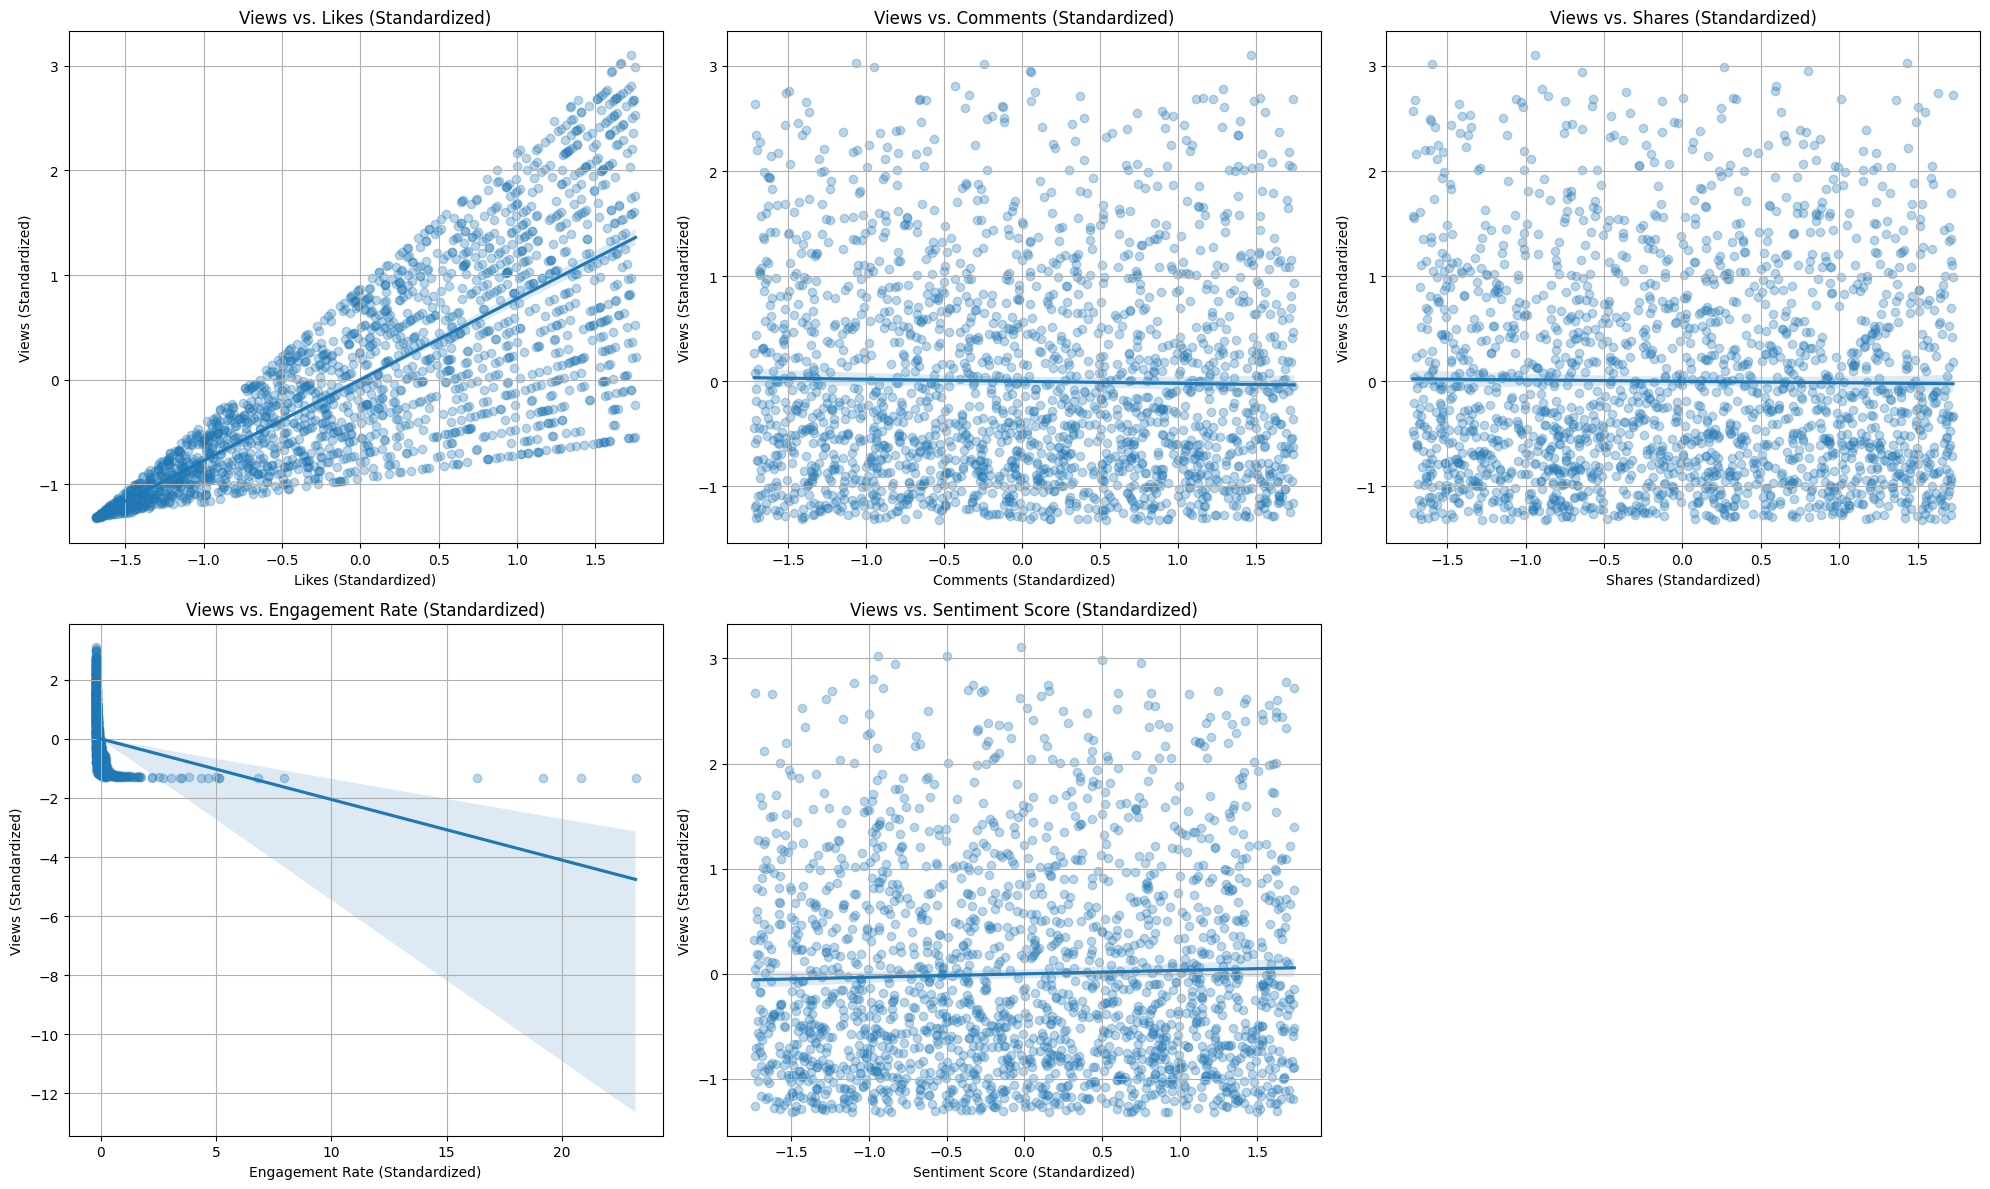

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Define the positive audience reactions features
positive_reactions_features = ['likes', 'comments', 'shares', 'engagement_rate', 'sentiment_score']

# Determine the optimal grid size for subplots
num_cols_per_row = 3  # You can adjust this number
num_plots = len(positive_reactions_features)
num_rows = math.ceil(num_plots / num_cols_per_row)

# Create figure and axes using plt.subplots
fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(20, num_rows * 6))

# Flatten the axes array for easy iteration if it's multi-dimensional
if num_rows > 1 or num_cols_per_row > 1:
    axes = axes.flatten()
else:
    axes = [axes] # Make it iterable for a single subplot case

for i, feature in enumerate(positive_reactions_features):
    ax = axes[i]
    sns.regplot(x=feature, y='views', data=df_encoded, scatter_kws={'alpha':0.3}, ax=ax)
    ax.set_title(f'Views vs. {feature.replace("_", " ").title()} (Standardized)')
    ax.set_xlabel(f'{feature.replace("_", " ").title()} (Standardized)')
    ax.set_ylabel('Views (Standardized)')
    ax.grid(True)

# Hide any unused subplots if the number of plots doesn't perfectly fill the grid
for j in range(num_plots, len(axes)):
    if j < len(axes):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Summary:

### Q&A
The analysis aimed to determine if positive audience reactions improve content popularity. The data partially supports this hypothesis. Specifically, 'likes' showed a strong, statistically significant positive impact on content 'views'. However, 'comments', 'shares', 'sentiment\_score', and TF-IDF hashtag features did not demonstrate a statistically significant positive impact.

### Data Analysis Key Findings
*   The `raw.csv` dataset was successfully loaded, inspected, and found to have no missing values or duplicate rows, with appropriate data types identified (e.g., `post_datetime` needing conversion).
*   Feature engineering involved removing `post_id` and identifying key columns for positive audience reactions and content popularity.
*   Categorical features (`platform`, `content_type`, `topic`, `language`, `region`) were successfully one-hot encoded, and TF-IDF was applied to `hashtags`, yielding 8 numerical features.
*   All numerical features, including the TF-IDF features, were standardized using `StandardScaler`.
*   Correlation analysis revealed a strong positive correlation between `likes` and `views` (0.77), and `is_viral` and `views` (0.66). However, `engagement_rate` showed a moderate negative correlation with `views` (-0.21), which is counter-intuitive. Individual TF-IDF hashtag features had no significant correlations.
*   A multiple linear regression model, including TF-IDF features, achieved an R-squared of approximately 0.603, indicating that about 60.3% of the variance in 'views' is explained by the independent variables.
*   Hypothesis testing confirmed that `likes` had a highly significant positive impact on `views` (coefficient = 0.7634, p-value = 0.000).
*   `Engagement_rate` had a statistically significant *negative* impact on `views` (coefficient = -0.0514, p-value = 0.000).
*   `Comments`, `shares`, `sentiment_score`, and all TF-IDF hashtag features did not show a statistically significant impact on `views` (all p-values > 0.05).

### Insights or Next Steps
*   **Investigate the 'engagement\_rate' anomaly**: The counter-intuitive negative correlation and significant negative impact of `engagement_rate` on `views` warrant deeper investigation into its calculation, potential confounding factors, or non-linear relationships.
*   **Explore advanced feature engineering for hashtags**: Given the limited impact of TF-IDF, consider more sophisticated NLP techniques like word embeddings or topic modeling to better capture the semantic value of hashtags.
